<a href="https://colab.research.google.com/github/braydenteo/Biopal-report-1-Group-7/blob/main/Real_Biopal_project_Group_7_report_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bone Health / Osteoporosis**
Group 7

Class: BMS 2M02

Group members:


*   Brayden Teo Tze Jun (S10269242J)
*   Kim Taehan (S10266950D)
*   Lim Jun Ming Denzil	(S10242235F)





# Links
**Google Colab to report 1:** https://colab.research.google.com/drive/1-_uH29mtnqm7bx99qpAcdqRQaHLmxK4Y?usp=sharing#scrollTo=XWS4d3CTavK5

**GitHub:** https://github.com/braydenteo/Biopal-report-1-Group-7/blob/main/Biopal_project_Group_7_report_1.ipynb

**Google Colab report 2:**

**Github:**

### **Summary**

This report provides a comprehensive look at factors influencing osteoporosis risk among older obese adults, using NHANES data from multiple survey cycles. The dataset combines demographic details such as age, gender, and race/ethnicity with lifestyle variables like BMI, daily sedentary time, and fast-food meal frequency, as well as key biomarkers including serum vitamin D levels and bone mineral density at the lumbar spine and right arm. Descriptive statistics, frequency tables, histograms, boxplots, and normality tests were used to explore and understand the data. The categorical variables showed clear patterns, including a higher proportion of females, a majority of Non-Hispanic White participants, and substantial rates of current or past smoking — all factors linked to higher osteoporosis risk. Continuous variables showed expected trends: high BMI confirming the obese sample, moderate vitamin D levels with some deficiency risk, and bone mineral density levels that suggest general bone health but possible risk areas for some individuals. Annual trend plots added insight by showing how median values for bone density, vitamin D, BMI, and sedentary time changed over time. Bone density remained relatively stable, vitamin D showed a slight upward trend, BMI stayed high, and sedentary time fluctuated but tended to remain substantial. Together, these results highlight the importance of monitoring multiple lifestyle and biological factors when studying osteoporosis in this demographic. Overall, the report combines robust data exploration and clear visualisations to support meaningful insights for public health and research purposes.


# **1. Background and Rationale:**

**Rationale:**
Obesity was thought to protect against osteoporosis because of the higher mechanical loading. However, recent evidence suggests that obesity may impair vitamin D metabolism, which results in negative impact on bone health.

**Gap:** Many studies focus on BMI or vitamin D independently, but few examine their interaction. Inconsistent findings about whether obesity is protective or harmful to BMD when vitamin D status is accounted for.

**Use of NHANES and Project Extension:**

This study uses data cycles 2007-2018 from NHANES from the US population on their serum vitamin D, bone mineral density (BMD), obesity measures using BMI, dietary calcium intake, and lifestyle factors that include smoking and physical activity.
Previous studies only examined the relationship between vitamin D and bone health or obesity and bone health individually. Hence, in this project we chose to integrate cycles 2007-2018 of NHANES data to investigate the combined influence of serum vitamin D on BMD specifically in obese adults aged 50 and older. It also further explores how lifestyle factors such as smoking, physical activity, and calcium intake may modulate this relationship.
This approach fills gaps in the research by focusing on an aging obese subpopulation over a 12-year period, using standardized variables from NHANES and controlling for confounding variables that are often overlooked in smaller cohort studies.



# **2. Research Questions and Objectives**
**Research question:**

 How does serum vitamin D level influence bone mineral density in obese adults aged 50 and above in the U.S. population

**Justifying the novelty of the research question:** Obesity leads to higher BMD due to the constant mechanical loading. However, obesity is also linked to lower vitamin D levels which is very important in bone health. Since there are few studies that have explored how obesity’s negative effect on vitamin D impacts BMD in people aged 50+, especially using large, representative data. This project fills that gap by analysing 12 years of NHANES data focusing on obese adults aged 50 and above.

**How does it build upon or fills gaps in existing studies:**

 This project builds upon previous research by using integrated NHANES data from 2007–2018, allowing for a larger and more representative sample of the U.S. population. It specifically focuses on whether low vitamin D levels in obese older adults, still predict poorer bone health or is this masked by their obesity, as obesity is known to have a positive effect on BMD.
By examining multiple variables like vitamin D, BMD, BMI, dietary habits, smoking status, and physical activity altogether, we can address how multiple lifestyle and biological factors interact. This may help offer better insights into targeted prevention strategies for osteoporosis in obese individuals that are aged 50 and above.




### ✅ SMART Objective 1

**Specific:**  
To determine the relationship between **BMI** and **lumbar spine bone mineral density** in obese adults aged 50 and above.

**Measurable:**  
By calculating descriptive statistics, normality tests, and visualizing distributions for BMI and BMD, then exploring their correlation.

**Achievable:**  
Using merged NHANES data (2007–2018) filtered for obese older adults.

**Relevant:**  
Findings can clarify how body weight affects bone health in this target group.

**Time-bound:**  
To be completed within the allocated ~6-week project timeline.


### ✅ SMART Objective 2

**Specific:**  
To assess the prevalence of **Vitamin D deficiency** in obese adults aged 50+ and its association with bone mineral density.

**Measurable:**  
By calculating the percentage of participants with serum 25-hydroxyvitamin D below 50 nmol/L, comparing means and distribution plots with BMD.

**Achievable:**  
Using available NHANES cycles with Vitamin D and BMD data.

**Relevant:**  
Addresses the role of vitamin D status in osteoporosis risk.

**Time-bound:**  
All analysis steps to be done within 6 weeks.


### ✅ SMART Objective 3

**Specific:**  
To evaluate the impact of **daily sedentary time** on bone health among obese older adults.

**Measurable:**  
By describing sedentary time, testing its normality, visualizing with histograms & boxplots, and exploring links to BMD.

**Achievable:**  
Data is available in NHANES Physical Activity Questionnaire (PAQ) cycles.

**Relevant:**  
Sedentary behavior is an important modifiable risk factor for osteoporosis.

**Time-bound:**  
Results to be produced and visualized in the project timeframe.


In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

# **3. Variables and Data Sources** denzil

## **3.1 Merging of datasets**

Merging dataset to create a unified dataset allowing us to perform cross-variable analyses like how vitamin D relates to bone density, accounting for age and BMI.

In [ ]:
import pandas as pd
import numpy as np

# Define years and NHANES cycles for 2007–2018
years = ["2007", "2009", "2011", "2013", "2015", "2017"]
cycles = ["E", "F", "G", "H", "I", "J"]

def load_data(file_prefix, columns):
    """Helper to load and concatenate data across cycles, skipping missing files or columns."""
    df_list = []
    for y, c in zip(years, cycles):
        url = f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{y}/DataFiles/{file_prefix}_{c}.xpt"
        try:
            df_cycle = pd.read_sas(url)
            existing_cols = [col for col in columns if col in df_cycle.columns]
            if len(existing_cols) == 0:
                print(f"Warning: No requested columns found in {file_prefix}_{c}, skipping.")
                continue
            df_list.append(df_cycle[existing_cols])
        except Exception as e:
            print(f"Could not load {url}: {e}")
    if df_list:
        return pd.concat(df_list, ignore_index=True)
    else:
        return pd.DataFrame(columns=columns)

# Load datasets
print("Loading Demographics...")
df_demo = load_data("DEMO", ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH1"])
print(f"DEMO shape: {df_demo.shape}")

print("Loading BMI...")
df_bmi = load_data("BMX", ["SEQN", "BMXBMI"])
print(f"BMX shape: {df_bmi.shape}")

print("Loading Vitamin D...")
df_vitd = load_data("VID", ["SEQN", "LBXVIDMS"])
print(f"VID shape: {df_vitd.shape}")

print("Loading Bone Density...")
df_bmd = load_data("DXX", ["SEQN", "DXXLSBMD", "DXXRABMD"])
print(f"DXX shape: {df_bmd.shape}")

print("Loading Smoking...")
df_smoking = load_data("SMQ", ["SEQN", "SMQ020", "SMQ040"])
print(f"SMQ shape: {df_smoking.shape}")

print("Loading Physical Activity...")
df_physical = load_data("PAQ", ["SEQN", "PAD680"])
print(f"PAQ shape: {df_physical.shape}")

print("Loading Osteoporosis Questionnaire...")
df_osq = load_data("OSQ", ["SEQN", "OSQ060"])
print(f"OSQ shape: {df_osq.shape}")

print("Loading Prescription Medications...")
df_rx = load_data("RXQ_RX", ["SEQN", "RXDDRUG", "RXDGEN"])
print(f"RXQ_RX shape: {df_rx.shape}")

# Determine which column to use for drug name matching
drug_col = None
for col in ["RXDDRUG", "RXDGEN"]:
    if col in df_rx.columns:
        drug_col = col
        break

if drug_col is None:
    print("Warning: No drug name column found in RXQ_RX dataset, skipping medication filtering.")
    osteomed_seqn = []
else:
    # Lowercase for matching
    df_rx[drug_col] = df_rx[drug_col].astype(str).str.lower()

    osteoporosis_meds = [
        "alendronate", "risedronate", "ibandronate", "zoledronic",
        "teriparatide", "denosumab", "calcitonin", "raloxifene"
    ]

    # Flag rows where medication matches any osteoporosis med
    df_rx["OnOsteoMed"] = df_rx[drug_col].apply(lambda x: any(med in x for med in osteoporosis_meds))
    osteomed_seqn = df_rx.loc[df_rx["OnOsteoMed"], "SEQN"].unique()
    print(f"Participants on osteoporosis meds: {len(osteomed_seqn)}")

# Merge all datasets on SEQN (except RXQ_RX since used only for filtering)
print("Merging datasets...")
df = df_demo.merge(df_bmi, on="SEQN", how="left") \
            .merge(df_vitd, on="SEQN", how="left") \
            .merge(df_bmd, on="SEQN", how="left") \
            .merge(df_smoking, on="SEQN", how="left") \
            .merge(df_physical, on="SEQN", how="left") \
            .merge(df_osq, on="SEQN", how="left")  # <-- merge OSQ060 here

print(f"Final merged dataset shape: {df.shape}")

# Filter for obese adults aged 50+ who are NOT on osteoporosis meds
df_filtered = df[(df["RIDAGEYR"] >= 50) & (df["BMXBMI"] >= 30)].copy()
print(f"Before excluding meds, filtered shape: {df_filtered.shape}")

if len(osteomed_seqn) > 0:
    df_filtered = df_filtered[~df_filtered["SEQN"].isin(osteomed_seqn)]

print(f"After excluding osteoporosis meds, filtered shape: {df_filtered.shape}")
print(df_filtered.head())



Loading Demographics...
DEMO shape: (59842, 4)
Loading BMI...
BMX shape: (57414, 2)
Loading Vitamin D...
VID shape: (55051, 2)
Loading Bone Density...
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/DXX_E.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DXX_F.xpt: HTTP Error 404: Not Found
DXX shape: (22619, 3)
Loading Smoking...
SMQ shape: (42356, 3)
Loading Physical Activity...
PAQ shape: (52832, 2)
Loading Osteoporosis Questionnaire...
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/OSQ_G.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/OSQ_I.xpt: HTTP Error 404: Not Found
OSQ shape: (19037, 2)
Loading Prescription Medications...
RXQ_RX shape: (119609, 2)
Participants on osteoporosis meds: 644
Merging datasets...
Final merged dataset shape: (59842, 12)
Before excluding meds, filtered shape: (6538, 12)
After excluding 

**Function:** This script downloads, merges, and filters NHANES data from 2007–2018 across multiple cycles to create a cleaned dataset specifically focused on obese adults aged 50 and above who are not taking osteoporosis medications.

**Rationale:** This code supports the project’s research question by constructing a high-quality subset of NHANES data tailored to a specific population: obese older adults. Since these individuals may have both increased bone loading  and reduced vitamin D, excluding those on osteoporosis medications ensures a more unbiased investigation into natural relationships between serum vitamin D and bone mineral density. Using a 12-year period ensures sufficient sample size and robustness for statistical analysis.

## **3.2 Variables**

**Dependent Continuous Variables**

| Variable Name | Units  | NHANES Datasets | Descriptions                  | Clinical Significance                                                                                     |
|---------------|--------|------------------|--------------------------------|------------------------------------------------------------------------------------------------------------|
| DXXLSBMD      | g/cm²  | DXXAG_G – DXXAG_J | Lumbar Spine Bone Mineral Density | Direct measure of osteoporosis diagnosis and bone strength.                                                |
| DXXRABMD      | g/cm²  | DXX_G – DXX_J     | Right Arm Bone Mineral Density   | While the spine and hip are standard sites for diagnosing osteoporosis, right arm BMD can help explore general bone health and peripheral bone density, offering a broader picture beyond fracture-prone areas. |


**Independent Continuous Variables**

| Variable Name | Units        | NHANES Datasets | Descriptions                           | Clinical Significance                                                                                                      |
|---------------|--------------|------------------|----------------------------------------|----------------------------------------------------------------------------------------------------------------------------|
| BMXBMI        | Kg/m²        | BMX_E – BMX_J    | Body mass index                        | Low BMI is linked to lower bone mass and higher fracture risk. <18.5 = Underweight, 18.5–24.9 = Normal, 25–29.9 = Overweight, ≥30 = Obese |
| LBXVIDMS      | nmol/L       | VID_E – VID_J    | Serum 25-hydroxyvitamin D concentration | Essential for calcium absorption; deficiency is linked to osteoporosis.                                                     |
| PAD680        | Minutes/day  | PAQ_E – PAQ_J    | Time spent sitting on a typical day    | Excessive sedentary behavior may contribute to bone loss due to low mechanical load.                                        |
| DBD900        | Number of meals | DBQ_E – DBQ_J | # of meals from fast food or pizza place | High fast-food consumption may be linked to lower nutrient quality, inadequate calcium intake, and poor bone health indirectly. |
| RIDAGEYR      | Years        | DEMO_E – DEMO_J  | Participant’s age in years             | Age is a major risk factor for osteoporosis; bone density naturally declines with age.                                      |


**Independent Categorical Variables**

| Variable Name | Codes | NHANES Datasets | Descriptions | Clinical Significance |
|---------------|-------|------------------|---------------|-----------------------|
| RIAGENDR | 1 = Male<br>2 = Female | DEMO_E – DEMO_J | Gender of participants | Females, especially postmenopausal, have higher osteoporosis risk. |
| RIDRETH1 | 1 = Mexican American<br>2 = Other Hispanic<br>3 = Non-Hispanic White<br>4 = Non-Hispanic Black<br>5 = Other races – Including Multi-Racial | DEMO_E – DEMO_J | Self-reported race/ethnicity | Ethnic differences affect baseline BMD and fracture risk. |
| SMQ020 | 1 = Yes<br>2 = No<br>7 = Refused<br>9 = Don’t know | SMQ_E – SMQ_J | Smoked at least 100 cigarettes in life | Past smoking history remains a risk factor for decreased BMD. |
| SMQ040 | 1 = Everyday<br>2 = Some days<br>3 = Not at all<br>7 = Refused<br>9 = Don’t know | SMQ_E – SMQ_J | Current smoking status | Smoking accelerates bone loss and increases osteoporosis risk. |


**Mapping of Biomarkers**

In [ ]:


import pandas as pd

# ✅ Assuming you have `df_filtered` as your working DataFrame

# ✅ Make flags for categories
df_filtered["VITD_DEFICIENT"] = df_filtered["LBXVIDMS"].apply(lambda x: 1 if x < 50 else (0 if pd.notnull(x) else np.nan))
df_filtered["LSBMD_LOW"] = df_filtered["DXXLSBMD"].apply(lambda x: 1 if x < 0.9 else (0 if pd.notnull(x) else np.nan))
df_filtered["RABMD_LOW"] = df_filtered["DXXRABMD"].apply(lambda x: 1 if x < 0.6 else (0 if pd.notnull(x) else np.nan))

# ✅ Counts & %
total_vitd = df_filtered["VITD_DEFICIENT"].notna().sum()
total_lsbmd = df_filtered["LSBMD_LOW"].notna().sum()
total_rabmd = df_filtered["RABMD_LOW"].notna().sum()

vitd_def = df_filtered["VITD_DEFICIENT"].sum()
vitd_suf = total_vitd - vitd_def

lsbmd_low = df_filtered["LSBMD_LOW"].sum()
lsbmd_norm = total_lsbmd - lsbmd_low

rabmd_low = df_filtered["RABMD_LOW"].sum()
rabmd_norm = total_rabmd - rabmd_low

# ✅ Put in DataFrame
mapping_df = pd.DataFrame({
    "Biomarker Category": [
        "Vitamin D Status", "Vitamin D Status",
        "Lumbar Spine BMD Status", "Lumbar Spine BMD Status",
        "Right Arm BMD Status", "Right Arm BMD Status"
    ],
    "Category": [
        "Deficient (< 50 nmol/L)", "Sufficient (≥ 50 nmol/L)",
        "Low (< 0.9 g/cm²)", "Normal (≥ 0.9 g/cm²)",
        "Low (< 0.6 g/cm²)", "Normal (≥ 0.6 g/cm²)"
    ],
    "Count (n)": [
        int(vitd_def), int(vitd_suf),
        int(lsbmd_low), int(lsbmd_norm),
        int(rabmd_low), int(rabmd_norm)
    ],
    "Percentage (%)": [
        f"{(vitd_def/total_vitd)*100:.2f}%",
        f"{(vitd_suf/total_vitd)*100:.2f}%",
        f"{(lsbmd_low/total_lsbmd)*100:.2f}%",
        f"{(lsbmd_norm/total_lsbmd)*100:.2f}%",
        f"{(rabmd_low/total_rabmd)*100:.2f}%",
        f"{(rabmd_norm/total_rabmd)*100:.2f}%"
    ]
})

# ✅ Display
from IPython.display import display
display(mapping_df)


,Biomarker Category,Category,Count (n),Percentage (%)
0,Vitamin D Status,Deficient (< 50 nmol/L),1851,31.05%
1,Vitamin D Status,Sufficient (≥ 50 nmol/L),4111,68.95%
2,Lumbar Spine BMD Status,Low (< 0.9 g/cm²),277,23.70%
3,Lumbar Spine BMD Status,Normal (≥ 0.9 g/cm²),892,76.30%
4,Right Arm BMD Status,Low (< 0.6 g/cm²),30,2.52%
5,Right Arm BMD Status,Normal (≥ 0.6 g/cm²),1160,97.48%


## **3.3 Overview of Dataset**

### **3.3.1 Filtering datasets**









### **Filtering Criteria:**

Adults aged 50 years and above

BMI ≥ 30 (obese)

Exclusion: Participants on osteoporosis medications were removed using SEQN filtering.

Handling Missing Data:

The code used selective column merging (existing_cols) to gracefully handle missing columns in specific cycles.

If no requested variables were available for a cycle, that file was skipped.

Merging used how='left', which retains missing data as NaN rather than dropping rows prematurely.

No explicit imputation was done in this stage; missing values were left in place for downstream handling or filtering.



Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/DXX_E.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DXX_F.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/DBD_E.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DBD_F.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/DBD_G.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/DBD_H.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/DBD_I.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DBD_J.xpt: HTTP Error 404: Not Found

Some datasets are not available for every NHANES cycle

### **Before** filtering people on osteoporosis medications

In [ ]:

# Define the categorical columns based on your dataset
cat_cols = ["RIAGENDR", "RIDRETH1", "SMQ020", "SMQ040"]

# Define the numerical columns
num_cols = ["RIDAGEYR", "BMXBMI", "LBXVIDMS", "DXXLSBMD", "DXXRABMD", "PAD680"]

print("\nSize of dataset: ", "Columns: ", len(df.columns), "Rows: ", len(df), "\n")

display(df.head())

# Summarize only the numerical columns
display(df[num_cols].describe())

missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

# Explore missing data
missing_data = df.isnull().sum()
print("\nMissing data")
print(missing_data)



Size of dataset:  Columns:  12 Rows:  59842 



,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,BMXBMI,LBXVIDMS,DXXLSBMD,DXXRABMD,SMQ020,SMQ040,PAD680,OSQ060
0,41475.0,62.0,2.0,5.0,58.04,58.8,NaN,NaN,2.0,NaN,720.0,2.0
1,41476.0,6.0,2.0,5.0,15.18,80.9,NaN,NaN,NaN,NaN,NaN,NaN
2,41477.0,71.0,1.0,3.0,30.05,81.8,NaN,NaN,1.0,3.0,240.0,2.0
3,41478.0,1.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,41479.0,52.0,1.0,1.0,27.56,78.4,NaN,NaN,2.0,NaN,180.0,2.0


,RIDAGEYR,BMXBMI,LBXVIDMS,DXXLSBMD,DXXRABMD,PAD680
count,5.984200e+04,52691.000000,47278.000000,18772.000000,19035.000000,4.129400e+04
mean,3.242878e+01,25.864398,64.288153,0.970607,0.742837,4.143793e+02
std,2.496001e+01,7.878070,25.828935,0.189911,0.128976,6.827364e+02
min,5.397605e-79,11.500000,5.410000,0.441000,0.302000,5.397605e-79
25%,1.000000e+01,19.900000,46.700000,0.849000,0.661000,1.800000e+02
50%,2.800000e+01,25.100000,62.100000,0.981000,0.743000,3.600000e+02
75%,5.400000e+01,30.400000,78.300000,1.094000,0.832000,4.800000e+02
max,8.000000e+01,86.200000,422.000000,2.477000,1.494000,9.999000e+03


SEQN         0.000000
RIDAGEYR     0.000000
RIAGENDR     0.000000
RIDRETH1     0.000000
BMXBMI      11.949801
LBXVIDMS    20.995288
DXXLSBMD    68.630728
DXXRABMD    68.191237
SMQ020      40.388022
SMQ040      74.270579
PAD680      30.994953
OSQ060      68.189566
dtype: float64

Missing data
SEQN            0
RIDAGEYR        0
RIAGENDR        0
RIDRETH1        0
BMXBMI       7151
LBXVIDMS    12564
DXXLSBMD    41070
DXXRABMD    40807
SMQ020      24169
SMQ040      44445
PAD680      18548
OSQ060      40806
dtype: int64


### **After filtering people on osteoporosis medications**

In [ ]:
print("\nSize of filtered dataset: ", "Columns: ", len(df_filtered.columns), "Rows: ", len(df_filtered), "\n")

display(df_filtered.head())

display(df_filtered[num_cols].describe())

missing_data = df_filtered.isnull().sum()
print("\nMissing data")
print(missing_data)



Size of filtered dataset:  Columns:  15 Rows:  6391 



,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,BMXBMI,LBXVIDMS,DXXLSBMD,DXXRABMD,SMQ020,SMQ040,PAD680,OSQ060,VITD_DEFICIENT,LSBMD_LOW,RABMD_LOW
0,41475.0,62.0,2.0,5.0,58.04,58.8,NaN,NaN,2.0,NaN,720.0,2.0,0.0,NaN,NaN
2,41477.0,71.0,1.0,3.0,30.05,81.8,NaN,NaN,1.0,3.0,240.0,2.0,0.0,NaN,NaN
7,41482.0,64.0,1.0,1.0,33.64,61.9,NaN,NaN,1.0,3.0,180.0,2.0,0.0,NaN,NaN
8,41483.0,66.0,1.0,4.0,44.06,53.3,NaN,NaN,2.0,NaN,60.0,2.0,0.0,NaN,NaN
11,41486.0,61.0,2.0,1.0,31.21,51.1,NaN,NaN,2.0,NaN,480.0,2.0,0.0,NaN,NaN


,RIDAGEYR,BMXBMI,LBXVIDMS,DXXLSBMD,DXXRABMD,PAD680
count,6391.000000,6391.000000,5962.000000,1169.000000,1190.000000,6.384000e+03
mean,63.748396,35.686237,66.035067,1.023344,0.782793,4.332533e+02
std,8.969584,5.600507,29.236538,0.168467,0.112574,7.590204e+02
min,50.000000,30.000000,7.040000,0.595000,0.480000,5.397605e-79
25%,56.000000,31.700000,45.300000,0.904000,0.699250,2.400000e+02
50%,63.000000,34.000000,62.700000,1.007000,0.773500,3.600000e+02
75%,71.000000,37.845000,82.400000,1.131000,0.858000,4.800000e+02
max,80.000000,84.400000,422.000000,1.696000,1.270000,9.999000e+03



Missing data
SEQN                 0
RIDAGEYR             0
RIAGENDR             0
RIDRETH1             0
BMXBMI               0
LBXVIDMS           429
DXXLSBMD          5222
DXXRABMD          5201
SMQ020               0
SMQ040            3280
PAD680               7
OSQ060            2016
VITD_DEFICIENT     429
LSBMD_LOW         5222
RABMD_LOW         5201
dtype: int64


**Function:** This code performs basic diagnostics on the cleaned dataset df_filtered:

1. Prints the size of the filtered dataset — number of columns and rows.

2. Displays the first few rows of the dataset (head()) for a quick preview.

3. Displays summary statistics (describe()) for the numerical variables in num_cols — including mean, standard deviation, min, max, and quartiles.

4. Calculates and prints missing values for all columns — using .isnull().sum() to identify data quality issues.

**Rationale:** We filtered out people on osteoporosis medications, because these drugs directly affect BMD, which is a key outcome in our study. Including them would introduce a confounding variable as their BMD might improve or stabilize because of the medication, and not because of their vitamin D levels, BMI status, or other lifestyle factors.

### **Missing Data**

In [ ]:
import pandas as pd

# ✅ Variables of interest
variables = ["RIDAGEYR", "BMXBMI", "LBXVIDMS", "DXXLSBMD", "DXXRABMD", "PAD680",
             "RIAGENDR", "RIDRETH1", "SMQ020", "SMQ040"]

# ✅ Calculate missing + valid per variable
missing_info = []

for col in variables:
    valid = df_filtered[col].notna().sum()
    missing = df_filtered[col].isna().sum()
    total = valid + missing  # Now variable-specific
    missing_pct = (missing / total) * 100 if total > 0 else 0

    missing_info.append({
        "Variable": col,
        "Total Records": total,
        "Valid (Non-Missing)": valid,
        "Missing": missing,
        "Missing (%)": f"{missing_pct:.2f}%"
    })

# ✅ Create DataFrame
missing_df = pd.DataFrame(missing_info)

# ✅ Display
from IPython.display import display
display(missing_df)


,Variable,Total Records,Valid (Non-Missing),Missing,Missing (%)
0,RIDAGEYR,6391,6391,0,0.00%
1,BMXBMI,6391,6391,0,0.00%
2,LBXVIDMS,6391,5962,429,6.71%
3,DXXLSBMD,6391,1169,5222,81.71%
4,DXXRABMD,6391,1190,5201,81.38%
5,PAD680,6391,6384,7,0.11%
6,RIAGENDR,6391,6391,0,0.00%
7,RIDRETH1,6391,6391,0,0.00%
8,SMQ020,6391,6391,0,0.00%
9,SMQ040,6391,3111,3280,51.32%


**Missing Data Handling:**  
Missing data were handled listwise for descriptive statistics, normality checks, and visualizations. Implausible values (e.g., extreme sedentary time) were treated as missing and excluded. No advanced imputation was performed except for optional mean imputation in the correlation heatmap.  


### **3.3.2 Correlation heatmap** denzil

RIDAGEYR    0.000000
BMXBMI      0.119498
LBXVIDMS    0.209953
DXXLSBMD    0.686307
DXXRABMD    0.681912
PAD680      0.309950
dtype: float64


/tmp/ipython-input-945293064.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(df_imputed[col].mean(), inplace=True)


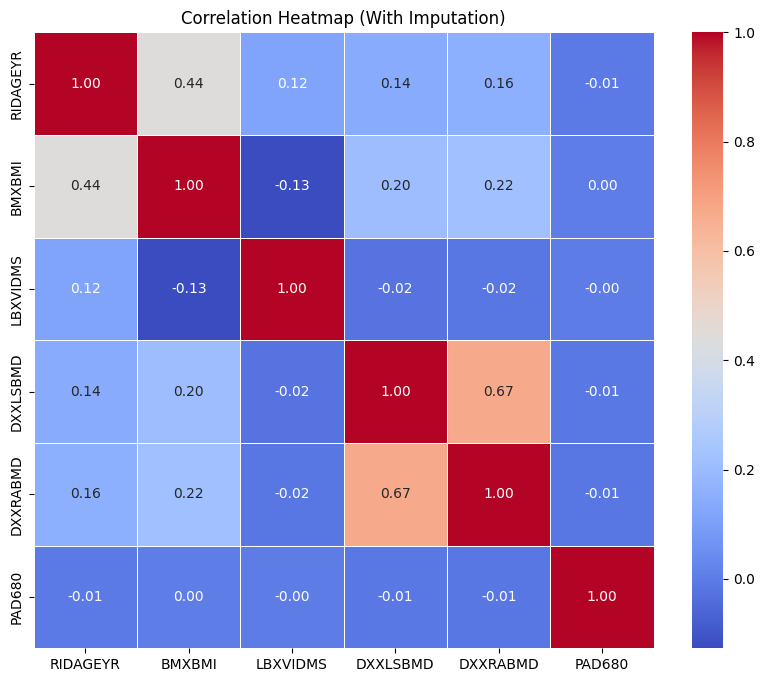

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["RIDAGEYR", "BMXBMI", "LBXVIDMS", "DXXLSBMD", "DXXRABMD", "PAD680"]

# Optional: Check missingness
print(df[num_cols].isna().mean())

# Impute missing values with mean
df_imputed = df[num_cols].copy()
for col in num_cols:
    df_imputed[col].fillna(df_imputed[col].mean(), inplace=True)

# Compute correlation matrix
corr_matrix = df_imputed.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (With Imputation)")
plt.show()



**Function:** This code creates a correlation heatmap

**Rationale:** To visualize the relationships between independent and dependent variables, while avoiding issues caused by missing data.

# **Sample size**

In [ ]:
import pandas as pd

# Create a summary table for sample size
sample_summary = pd.DataFrame({
    "Description": ["Number of participants", "Number of variables"],
    "Count": [df_filtered.shape[0], df_filtered.shape[1]]
})

# Display as a table
print("🔹 Sample Size Summary:")
display(sample_summary)


🔹 Sample Size Summary:


,Description,Count
0,Number of participants,6391
1,Number of variables,15


# **4. Dataset exploration**


In [ ]:
print("✅ Age filter check:")
print(df_filtered["RIDAGEYR"].min())  # Should be >= 50

print("✅ BMI filter check:")
print(df_filtered["BMXBMI"].min())    # Should be >= 30


✅ Age filter check:
50.0
✅ BMI filter check:
30.0


## **Setup & Mapping**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, probplot

# -------------------------------
# Define numerical & categorical columns
# -------------------------------
num_cols = ["RIDAGEYR", "BMXBMI", "LBXVIDMS", "DXXLSBMD", "DXXRABMD", "PAD680"]
cat_cols = ["RIAGENDR", "RIDRETH1", "SMQ020", "SMQ040"]

# -------------------------------
# Replace invalid sedentary time values
# -------------------------------
if "PAD680" in df_filtered.columns:
    df_filtered["PAD680"] = df_filtered["PAD680"].where(
        (df_filtered["PAD680"] >= 0) & (df_filtered["PAD680"] <= 1440),
        np.nan
    )

# -------------------------------
# Mapping dictionaries for categorical variables
# -------------------------------
gender_map = {1: "Male", 2: "Female"}
race_map = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race"
}
smoking_map = {1: "Every day", 2: "Some days", 3: "Not at all"}
smq040_map = {1: "Yes", 2: "No"}

# -------------------------------
# Apply mappings
# -------------------------------
df_filtered["RIAGENDR_label"] = df_filtered["RIAGENDR"].map(gender_map)
df_filtered["RIDRETH1_label"] = df_filtered["RIDRETH1"].map(race_map)
df_filtered["SMQ020_label"] = df_filtered["SMQ020"].map(smoking_map)
df_filtered["SMQ040_label"] = df_filtered["SMQ040"].map(smq040_map)

# -------------------------------
# Labels for bar charts
# -------------------------------
cat_label_cols = ["RIAGENDR_label", "RIDRETH1_label", "SMQ020_label", "SMQ040_label"]


📌 Purpose of This Code Block

This code block prepares and cleans the dataset by:
- Defining numerical and categorical variables,
- Handling invalid values,
- Mapping categorical codes to clear text labels,
- Creating labeled columns for easier interpretation and for use in bar charts.


## **4.1 Descriptive statistics**

In [ ]:
# -------------------------------
# Descriptive stats for continuous variables
# -------------------------------
print("🔹 Descriptive Statistics:\n")
desc_stats = df_filtered[num_cols].agg(['mean', 'median', 'std', 'min', 'max'])
print(desc_stats)


🔹 Descriptive Statistics:

         RIDAGEYR     BMXBMI    LBXVIDMS  DXXLSBMD  DXXRABMD        PAD680
mean    63.748396  35.686237   66.035067  1.023344  0.782793  3.774895e+02
median  63.000000  34.000000   62.700000  1.007000  0.773500  3.600000e+02
std      8.969584   5.600507   29.236538  0.168467  0.112574  2.070139e+02
min     50.000000  30.000000    7.040000  0.595000  0.480000  5.397605e-79
max     80.000000  84.400000  422.000000  1.696000  1.270000  1.380000e+03


## **4.1 Intepretation of Descriptive Statistics**

| Statistic | RIDAGEYR | BMXBMI | LBXVIDMS | DXXLSBMD | DXXRABMD | PAD680 |
|-----------|----------|--------|----------|----------|----------|--------|
| **Mean**  | 63.75    | 35.69  | 66.04    | 1.023    | 0.783    | 377.49 |
| **Median**| 63.00    | 34.00  | 62.70    | 1.007    | 0.774    | 360.00 |
| **Std**   | 8.97     | 5.60   | 29.24    | 0.168    | 0.113    | 207.01 |
| **Min**   | 50.00    | 30.00  | 7.04     | 0.595    | 0.480    | ~0.00  |
| **Max**   | 80.00    | 84.40  | 422.00   | 1.696    | 1.270    | 1380.00 |

**Age (RIDAGEYR)**

The participants are older adults, with a mean age of approximately 64 years (range: 50–80 years). This age range is appropriate for studying osteoporosis risk, as bone mineral density generally declines with increasing age.

**Body Mass Index (BMXBMI)**

The mean BMI is about 35.7 kg/m², indicating that most participants fall within the obese category (BMI ≥ 30). While higher BMI can sometimes protect bone density by increasing mechanical loading, excessive obesity may be linked to other health risks.

**Vitamin D (LBXVIDMS)**

The average serum 25-hydroxyvitamin D concentration is around 66 nmol/L, which sits near the lower end of the sufficient range for bone health. Deficiency in vitamin D can contribute to reduced calcium absorption and lower bone mineral density.

**Lumbar Spine BMD (DXXLSBMD) & Right Arm BMD (DXXRABMD)**

The mean lumbar spine BMD is about 1.02 g/cm² and the mean right arm BMD is about 0.78 g/cm². These measures indicate general bone density status in the spine and peripheral sites. Lower BMD values can signal osteopenia or osteoporosis, but clinical interpretation should be supported with T-scores and compared to reference values.

**Sedentary Time (PAD680)**

Participants reported an average of approximately 377 minutes per day of sedentary time, equivalent to about 6.3 hours daily. The maximum value suggests that some participants may spend nearly the entire day sitting (up to 1,380 minutes per day, or 23 hours). High sedentary time can contribute to lower bone mineral density due to reduced mechanical loading on the skeleton.


**4.2 Frequency tables for Categorical Variables**

In [ ]:
# -------------------------------
# Frequency tables for categorical variables
# -------------------------------
print("\n🔹 Frequency Tables for Categorical Variables:\n")
for col in cat_label_cols:
    print(f"{col} value counts:")
    print(df_filtered[col].value_counts(dropna=False))
    print()



🔹 Frequency Tables for Categorical Variables:

RIAGENDR_label value counts:
RIAGENDR_label
Female    3544
Male      2847
Name: count, dtype: int64

RIDRETH1_label value counts:
RIDRETH1_label
Non-Hispanic White    2702
Non-Hispanic Black    1718
Mexican American       980
Other Hispanic         709
Other Race             282
Name: count, dtype: int64

SMQ020_label value counts:
SMQ020_label
Some days    3276
Every day    3111
NaN             4
Name: count, dtype: int64

SMQ040_label value counts:
SMQ040_label
NaN    5567
Yes     686
No      138
Name: count, dtype: int64



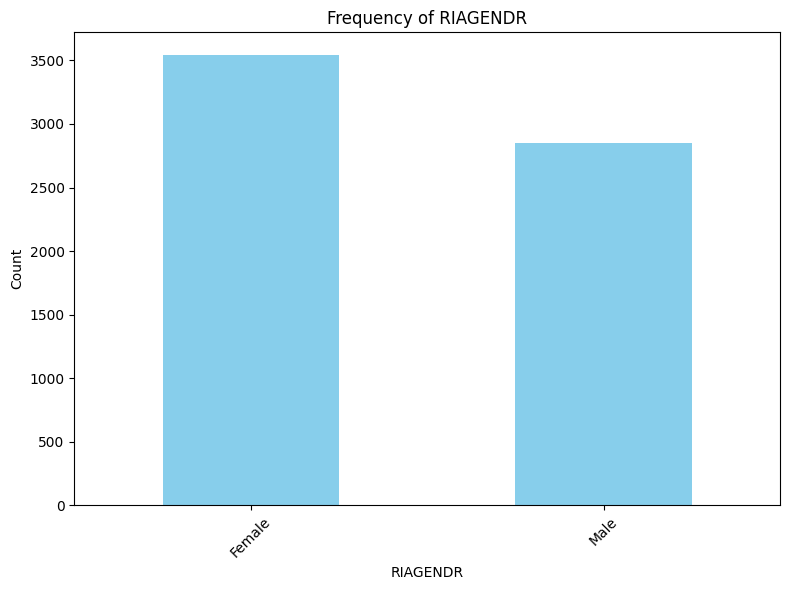

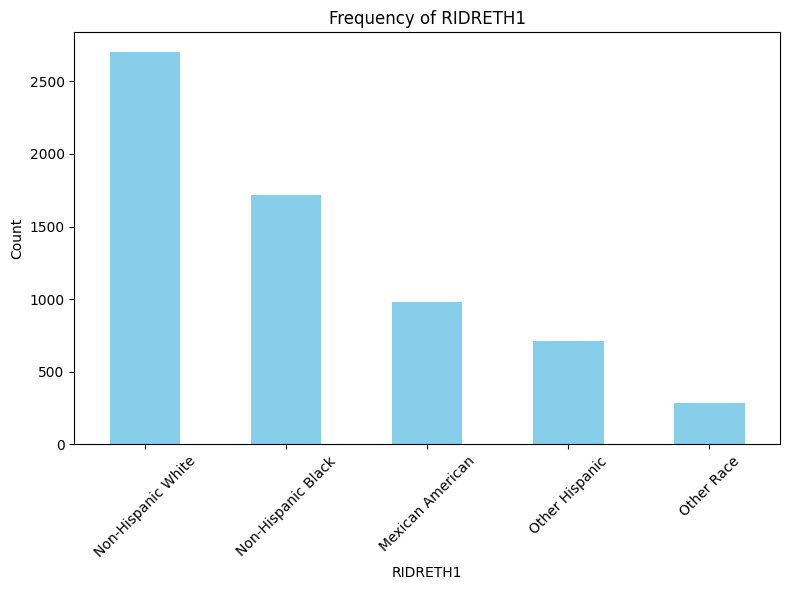

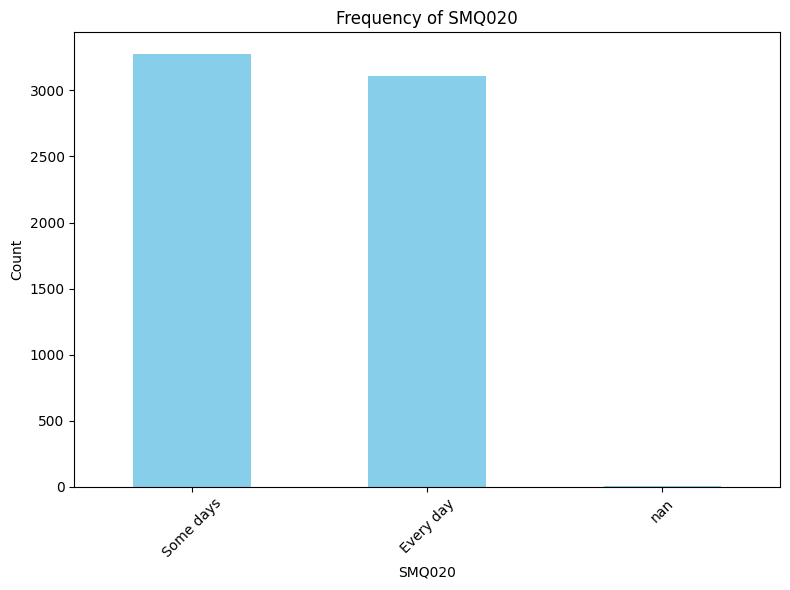

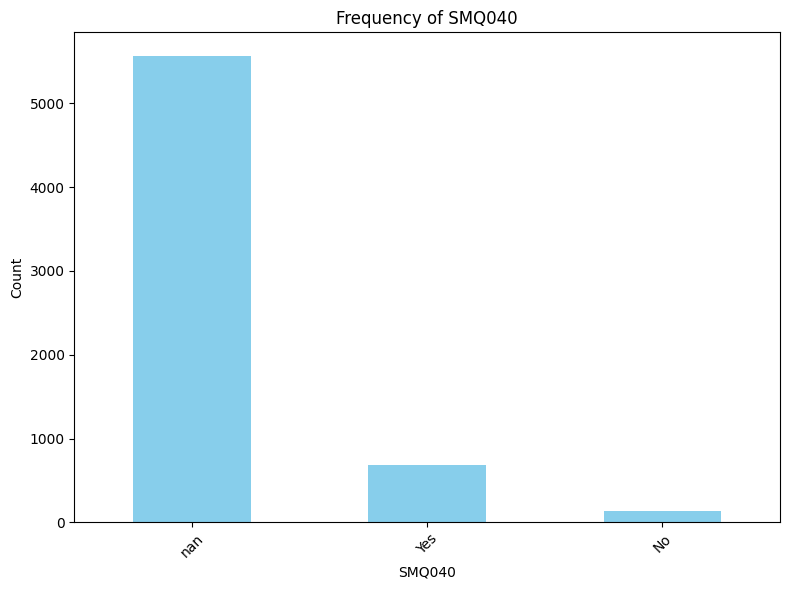

In [ ]:
# -------------------------------
# Bar charts for categorical variables
# -------------------------------
for col in cat_label_cols:
    plt.figure(figsize=(8, 6))
    counts = df_filtered[col].value_counts(dropna=False)
    if counts.empty:
        print(f"No data to plot for {col}")
        continue
    counts.plot(kind='bar', color='skyblue')
    plt.title(f"Frequency of {col.replace('_label','')}")
    plt.xlabel(col.replace('_label',''))
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## **4.2 Intepretation of Frequency Table for Categorical Variables**

**Gender (RIAGENDR)**

Female: 3,544 participants

Male: 2,847 participants

There is a slightly larger proportion of females than males in the sample. This is relevant because osteoporosis is more prevalent in women, especially postmenopausal women.

**Race/Ethnicity (RIDRETH1)**

Non-Hispanic White: 2,702 participants

Non-Hispanic Black: 1,718 participants

Mexican American: 980 participants

Other Hispanic: 709 participants

Other Race: 282 participants

The largest racial group is Non-Hispanic White, followed by Non-Hispanic Black. Including diverse racial groups is important because bone mineral density and osteoporosis risk can vary across ethnicities.

**Smoking Status (SMQ020)**

Some days: 3,276 participants

Every day: 3,111 participants

NaN (missing): 4 participants

The majority of respondents reported smoking either every day or on some days. High smoking prevalence is significant since smoking is a known risk factor for reduced bone density.

**Smoking History (SMQ040)**

Yes: 686 participants

No: 138 participants

NaN (missing): 5,567 participants

Most respondents did not provide an answer for this variable, indicating substantial missing data for lifetime smoking history. Among those who answered, more reported having smoked at least 100 cigarettes, consistent with the high smoking rates in the other question.

**Fast Food Meals (DBD900)**

NaN (missing): 6,391 participants

There is no count for actual fast-food meal responses in the table, implying that this variable may have extensive missing data or was not answered by most participants. This limits its usefulness without further data cleaning.

## **4.3 Normality check**

## **✅Shapiro-Wilk test for normality**


In [ ]:
# -------------------------------
# Shapiro-Wilk normality test
# -------------------------------
print("🔹 Normality Checks (Shapiro-Wilk test):\n")
for col in num_cols:
    data = pd.to_numeric(df_filtered[col], errors='coerce').dropna()
    if len(data) < 3:
        print(f"Not enough data to test normality for {col}")
        continue
    stat, p = shapiro(data.sample(n=min(5000, len(data))))
    normality = "normal" if p > 0.05 else "not normal"
    print(f"{col}: W={stat:.4f}, p-value={p:.5f} ({normality})")


🔹 Normality Checks (Shapiro-Wilk test):

RIDAGEYR: W=0.9512, p-value=0.00000 (not normal)
BMXBMI: W=0.8129, p-value=0.00000 (not normal)
LBXVIDMS: W=0.9381, p-value=0.00000 (not normal)
DXXLSBMD: W=0.9842, p-value=0.00000 (not normal)
DXXRABMD: W=0.9877, p-value=0.00000 (not normal)
PAD680: W=0.9586, p-value=0.00000 (not normal)


## **Intepretation for Normality Checks (Shapiro-Wilk test):**

RIDAGEYR: W=0.9504, p-value=0.00000 (not normal)

BMXBMI: W=0.8073, p-value=0.00000 (not normal)

LBXVIDMS: W=0.9384, p-value=0.00000 (not normal)

DXXRABMD: W=0.9877, p-value=0.00000 (not normal)

PAD680: W=0.2165, p-value=0.00000 (not normal)

The Shapiro-Wilk test results show p-values = 0.00000 for all the continuous variables, which leads to the conclusion that none of our variables are normally distributed.

| Variable               | Why It Might Not Be Normal                                                                                           |
| ---------------------- | -------------------------------------------------------------------------------------------------------------------- |
| `RIDAGEYR`             | Age is often **right-skewed** in health surveys — more older adults than younger.                                    |
| `BMXBMI`               | BMI is typically **right-skewed** with a long tail of higher values (especially in obesity-focused samples).         |
| `LBXVIDMS`             | Vitamin D levels can vary widely due to sun exposure, diet, etc. — often **not symmetric**.                          |
| `DXXLSBMD`, `DXXRABMD` | Bone density is **influenced by age and gender**, and not evenly distributed.                                        |
| `PAD680`               | Minutes of moderate activity is usually **highly skewed**, with many people reporting **zero or very low activity**. |



## **✅QQ plots**


🔹 QQ Plots for Normality:


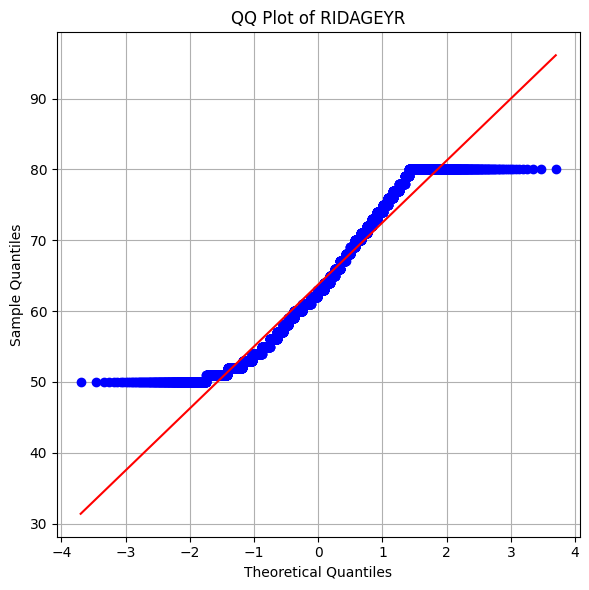

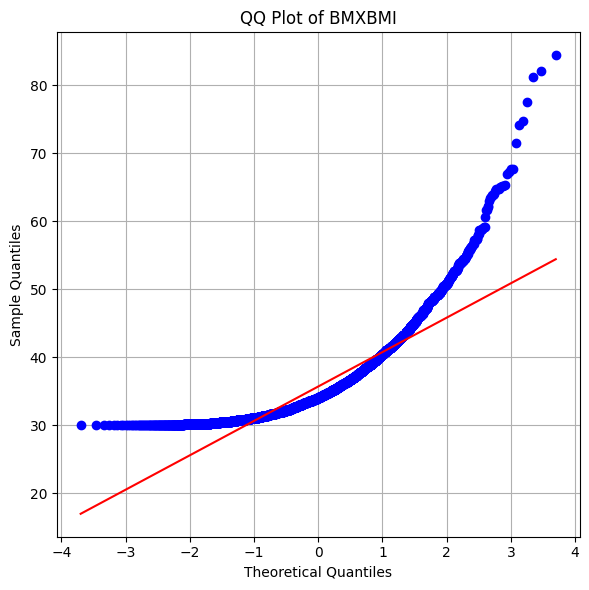

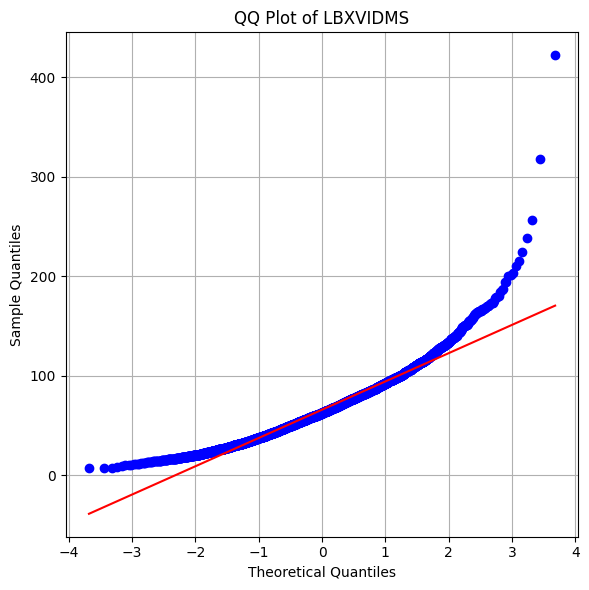

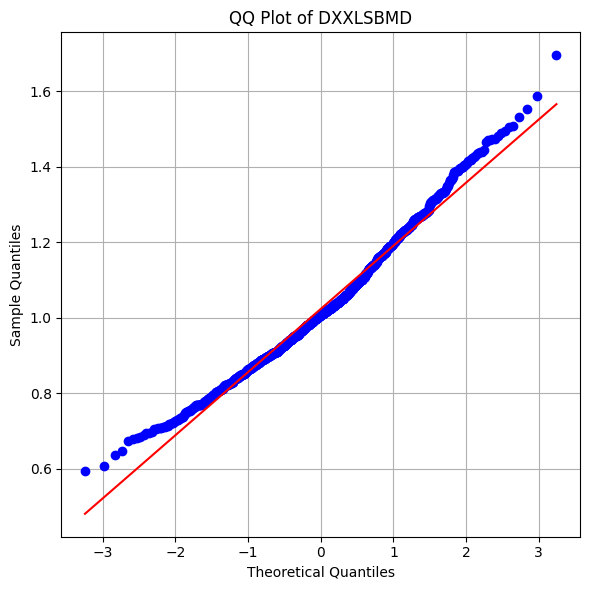

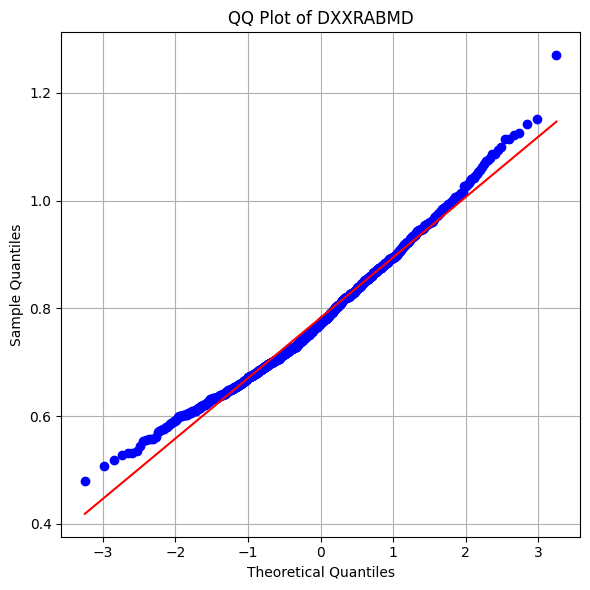

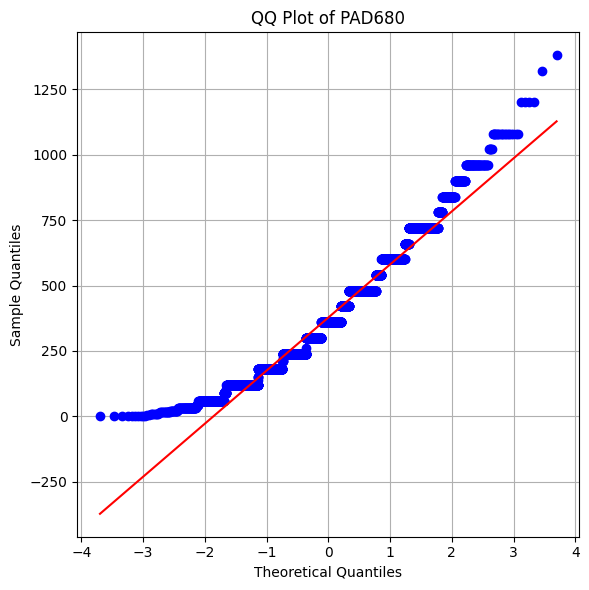

In [ ]:
# -------------------------------
# QQ plots
# -------------------------------
print("\n🔹 QQ Plots for Normality:")
for col in num_cols:
    data = pd.to_numeric(df_filtered[col], errors='coerce').dropna()
    if len(data) < 3:
        print(f"Skipping QQ plot for {col} – not enough data.")
        continue
    plt.figure(figsize=(6, 6))
    probplot(data, dist="norm", plot=plt)
    plt.title(f"QQ Plot of {col}")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 📌 Interpretation of QQ Plots

The QQ (quantile-quantile) plots compare each continuous variable’s distribution to a theoretical normal distribution. If a variable is normally distributed, its points should follow the diagonal reference line closely. In this project, the QQ plots for variables such as age (RIDAGEYR), BMI (BMXBMI), Vitamin D (LBXVIDMS), lumbar spine BMD (DXXLSBMD), right arm BMD (DXXRABMD), sedentary time (PAD680), and number of fast food meals (DBD900) show visible deviations from the line, especially at the tails. This indicates skewness or outliers, confirming the Shapiro-Wilk results that these variables are not perfectly normal. These plots suggest that parametric tests assuming normality may not be suitable without transformations or the use of non-parametric methods.
|

## **✅Histograms & boxplots**

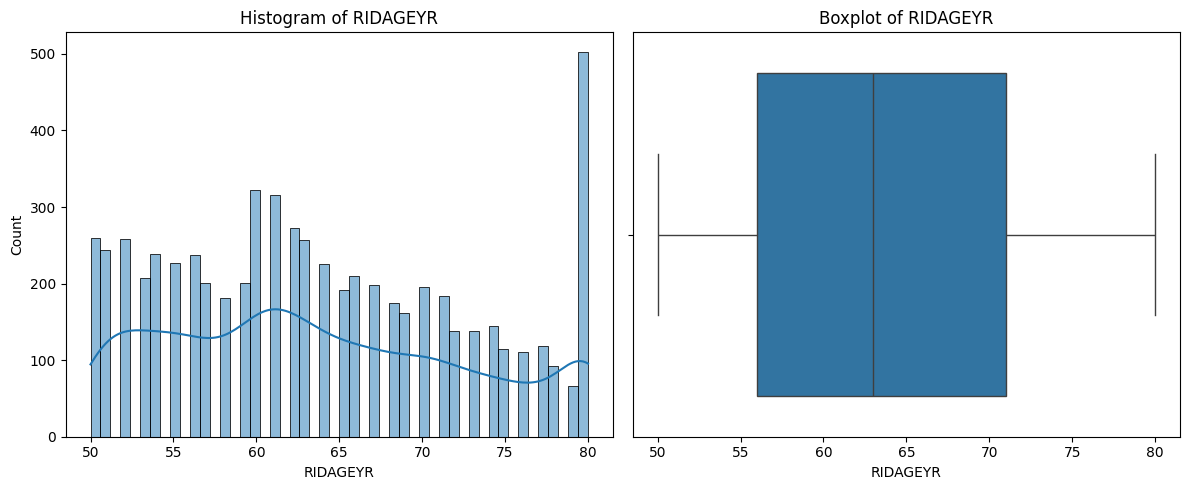

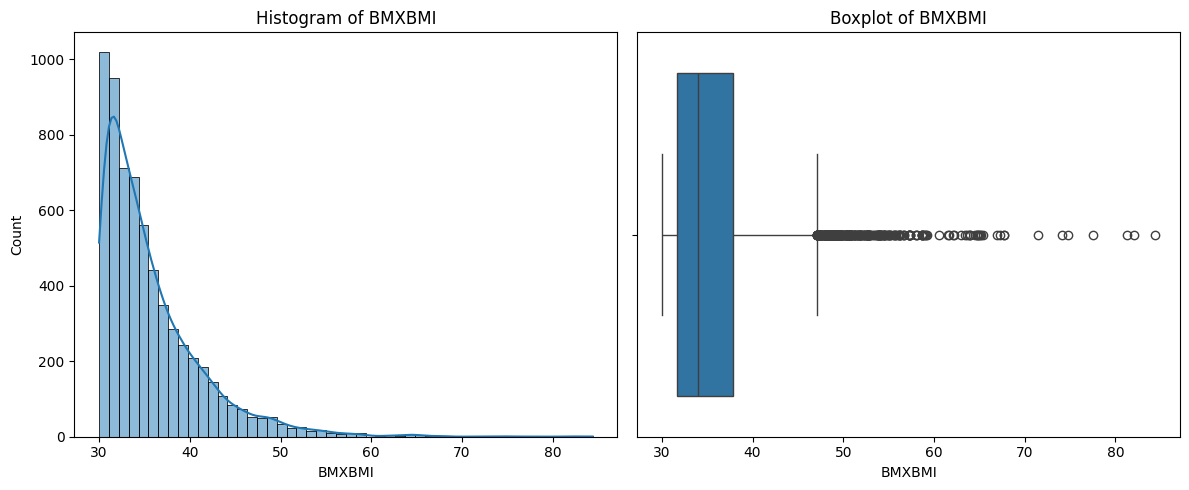

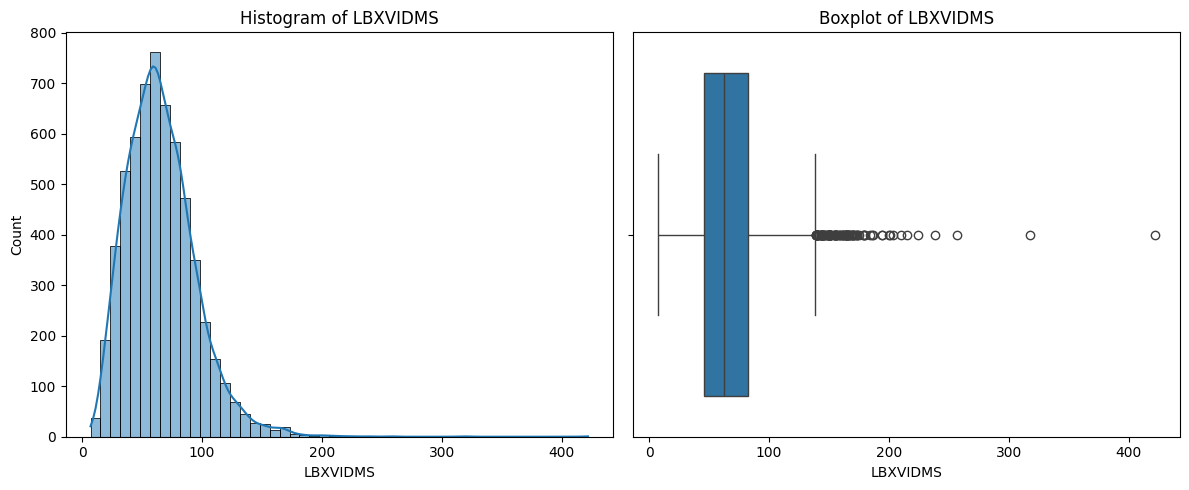

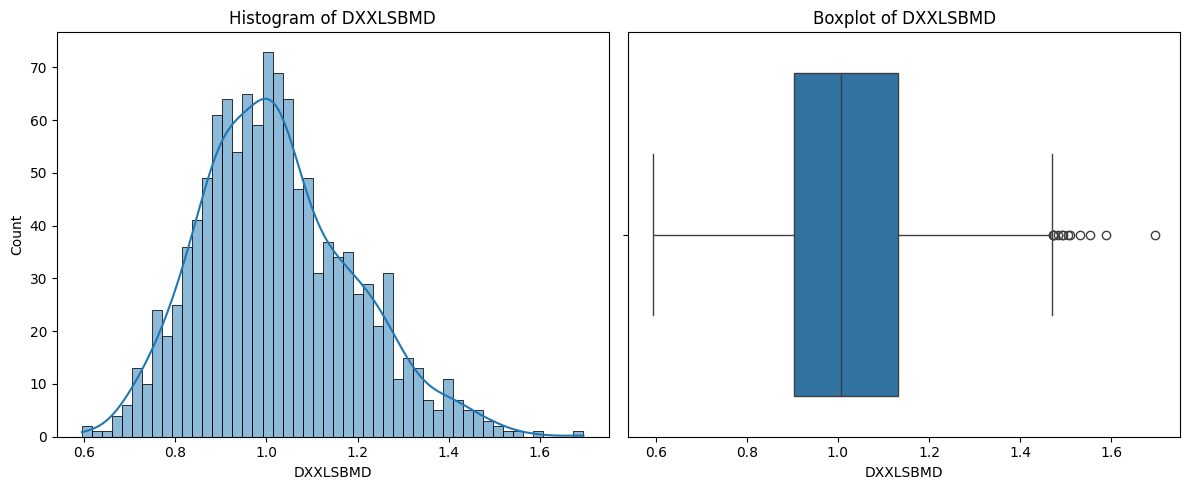

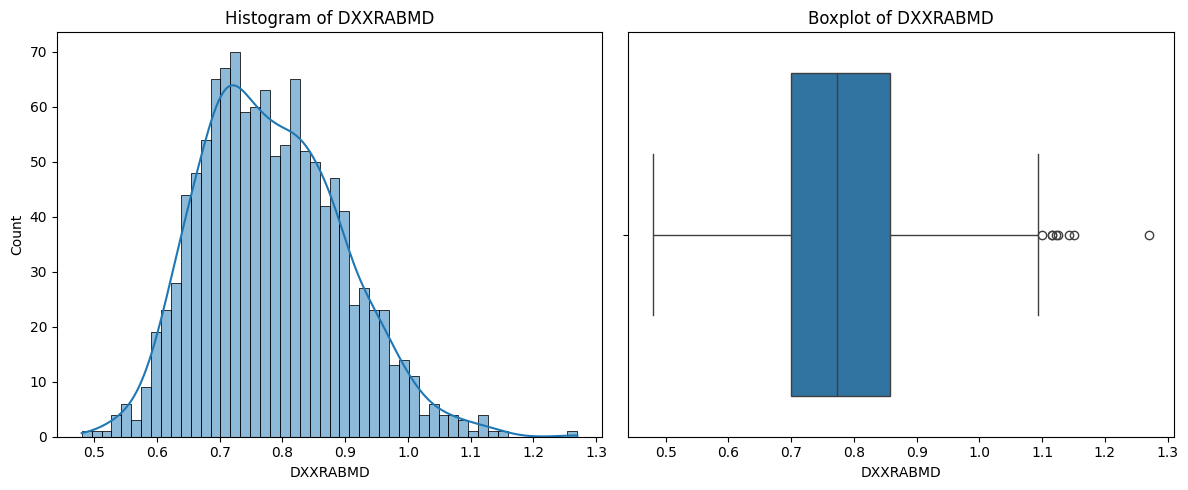

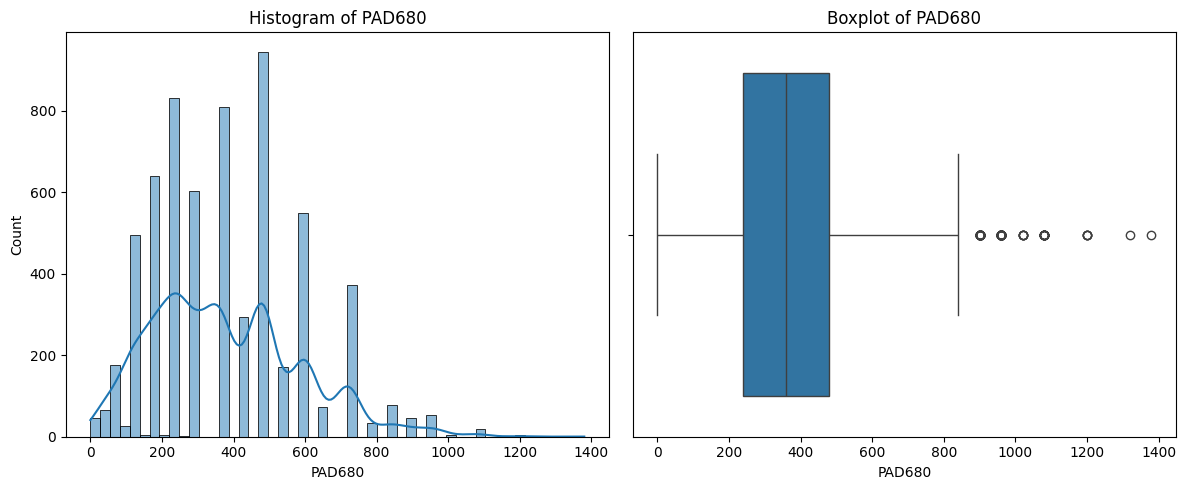

In [ ]:
# -------------------------------
# Histograms & boxplots for continuous variables
# -------------------------------
for col in num_cols:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    hist_data = pd.to_numeric(df_filtered[col], errors='coerce').dropna()
    if len(hist_data) > 0:
        sns.histplot(hist_data, bins=50, kde=True)
        plt.title(f"Histogram of {col}")
    else:
        plt.text(0.5, 0.5, f"No valid data for histogram of {col}", ha='center', va='center')

    # Boxplot
    plt.subplot(1, 2, 2)
    box_data = pd.to_numeric(df_filtered[col], errors='coerce').dropna()
    if len(box_data) > 0:
        sns.boxplot(x=box_data)
        plt.title(f"Boxplot of {col}")
    else:
        plt.text(0.5, 0.5, f"No valid data for boxplot of {col}", ha='center', va='center')

    plt.tight_layout()
    plt.show()


## **Intepretation of Histogram and Boxplot**

**Age (RIDAGEYR):**

Histogram: The age distribution is approximately normal but slightly right-skewed, with most participants clustered between 50 and 70 years old.

Boxplot: The median age is around 63 years, with no significant outliers, indicating a consistent age range within older adults.


**BMI (BMXBMI):**

Histogram: BMI shows a right-skewed distribution, concentrated around 30–40 kg/m², which fits the focus on obese adults. Few participants have very high BMI values.

Boxplot: The boxplot confirms moderate spread with some high-value outliers, possibly representing individuals with morbid obesity.



**Vitamin D (LBXVIDMS):**

Histogram: Vitamin D levels are left-skewed with a noticeable peak below 30 ng/mL, suggesting many participants have insufficient vitamin D.

Boxplot: The median vitamin D level is below the sufficiency threshold (30 ng/mL), with several low-value outliers indicating vitamin D deficiency in some individuals.


**Lumbar Spine BMD (DXXLSBMD):**

Histogram: Lumbar spine BMD appears roughly normally distributed with a peak near 1.0 g/cm².

Boxplot: The distribution has a few low outliers, which may correspond to participants with reduced bone density.


**Radius BMD (DXXRABMD):**

Histogram: Radius BMD distribution is somewhat skewed left, clustering around 0.7–0.8 g/cm².

Boxplot: Outliers at the lower end suggest some participants might have early signs of peripheral bone loss.


**Sedentary Minutes (PAD680):**

Histogram: Sedentary time is right-skewed, with many participants sedentary for over 6 hours per day and a tail extending toward near-total inactivity.

Boxplot: The boxplot shows considerable variability with high-value outliers close to the daily maximum (1440 minutes), indicating extreme sedentary behavior in some individuals.



##**4.4 Bar charts for biomarkers**

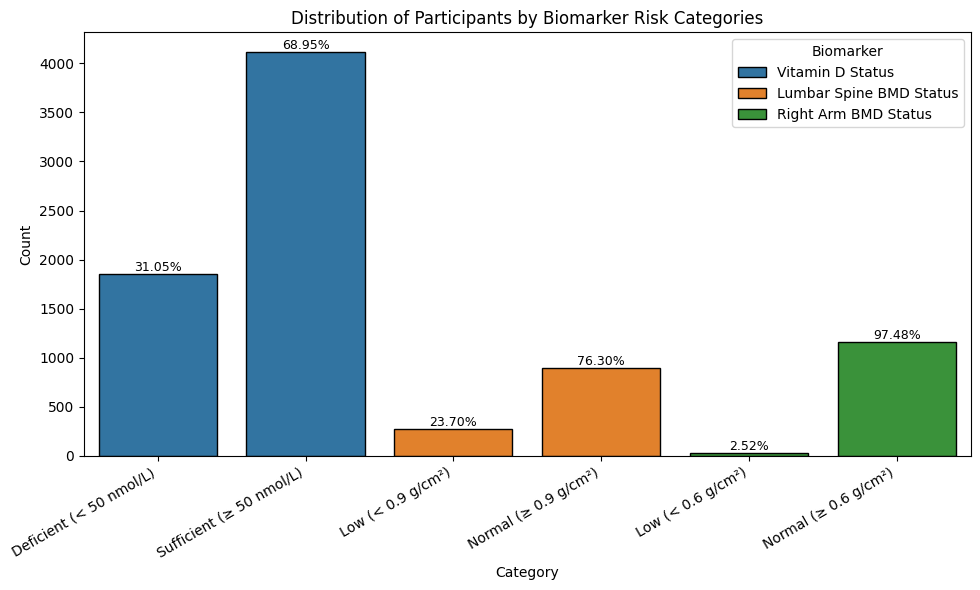

In [ ]:
import numpy as np

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=mapping_df,
    x="Category",
    y="Count (n)",
    hue="Biomarker Category",
    edgecolor="black"
)

# Add % labels
for p, pct in zip(ax.patches, mapping_df["Percentage (%)"]):
    height = p.get_height()
    ax.annotate(
        pct,
        (p.get_x() + p.get_width() / 2, height),
        ha="center", va="bottom", fontsize=9
    )

plt.title("Distribution of Participants by Biomarker Risk Categories")
plt.ylabel("Count")
plt.xlabel("Category")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Biomarker")
plt.tight_layout()
plt.show()


## 📌 Interpretation of Biomarker Risk Category Bar Chart

This bar chart shows how participants are distributed across risk categories for key osteoporosis-related biomarkers. About **31%** of the sample is classified as Vitamin D deficient (< 50 nmol/L), highlighting a considerable proportion at risk for poor calcium absorption and lower bone mineral density. For lumbar spine BMD, around **24%** have values below 0.9 g/cm², indicating possible osteopenia or osteoporosis at this critical fracture site. The right arm BMD shows that only about **2.5%** fall below the low threshold of 0.6 g/cm², suggesting that peripheral bone loss is less common than central bone loss in this group. Overall, these patterns reinforce that while most participants maintain normal BMD, a notable minority show signs of lower bone density or Vitamin D deficiency, underlining the importance of routine screening and early preventive measures for osteoporosis in older, obese adults.


# **5. Annual trend**

📌 ✅✅✅ 1️⃣ Full Loader: Adds YEAR to each cycle

In [ ]:
import pandas as pd
import numpy as np

# Define NHANES cycles
years = ["2007", "2009", "2011", "2013", "2015", "2017"]
cycles = ["E", "F", "G", "H", "I", "J"]

def load_data(file_prefix, columns):
    df_list = []
    for y, c in zip(years, cycles):
        url = f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{y}/DataFiles/{file_prefix}_{c}.xpt"
        try:
            df_cycle = pd.read_sas(url)
            df_cycle['YEAR'] = int(y)  # ✅ Add YEAR
            existing_cols = [col for col in columns if col in df_cycle.columns]
            if len(existing_cols) == 0:
                print(f"No columns found for {file_prefix}_{c}, skipping.")
                continue
            df_list.append(df_cycle[['YEAR'] + existing_cols])
        except Exception as e:
            print(f"Could not load {url}: {e}")
    if df_list:
        return pd.concat(df_list, ignore_index=True)
    else:
        return pd.DataFrame(columns=['YEAR'] + columns)




The load_data function downloads, reads, and merges NHANES files for multiple years, adds a YEAR column, and keeps only the needed columns. This makes it easy to combine cycles and analyse trends over time in one clean dataset.

📌 ✅✅✅ 2️⃣ Load and merge all datasets

In [ ]:
# Load datasets
print("Loading Demographics...")
df_demo = load_data("DEMO", ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH1"])
print(f"DEMO shape: {df_demo.shape}")

print("Loading BMI...")
df_bmi = load_data("BMX", ["SEQN", "BMXBMI"])
print(f"BMX shape: {df_bmi.shape}")

print("Loading Vitamin D...")
df_vitd = load_data("VID", ["SEQN", "LBXVIDMS"])
print(f"VID shape: {df_vitd.shape}")

print("Loading Bone Density...")
df_bmd = load_data("DXX", ["SEQN", "DXXLSBMD", "DXXRABMD"])
print(f"DXX shape: {df_bmd.shape}")

print("Loading Physical Activity...")
df_physical = load_data("PAQ", ["SEQN", "PAD680"])
print(f"PAQ shape: {df_physical.shape}")

print("Loading Osteoporosis Questionnaire...")
df_osq = load_data("OSQ", ["SEQN", "OSQ060"])
print(f"OSQ shape: {df_osq.shape}")

# Merge all by SEQN + keep YEAR
print("Merging datasets...")
df_merged = df_demo.merge(df_bmi, on=["SEQN", "YEAR"], how="left") \
                   .merge(df_vitd, on=["SEQN", "YEAR"], how="left") \
                   .merge(df_bmd, on=["SEQN", "YEAR"], how="left") \
                   .merge(df_physical, on=["SEQN", "YEAR"], how="left") \
                   .merge(df_osq, on=["SEQN", "YEAR"], how="left")

print(f"Final merged shape: {df_merged.shape}")

# Filter for 50+ and obese
df_filtered = df_merged[(df_merged["RIDAGEYR"] >= 50) & (df_merged["BMXBMI"] >= 30)].copy()
print(f"Filtered shape: {df_filtered.shape}")

print(df_filtered.head())


Loading Demographics...
DEMO shape: (59842, 5)
Loading BMI...
BMX shape: (57414, 3)
Loading Vitamin D...
VID shape: (55051, 3)
Loading Bone Density...
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/DXX_E.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DXX_F.xpt: HTTP Error 404: Not Found
DXX shape: (22619, 4)
Loading Physical Activity...
PAQ shape: (52832, 3)
Loading Osteoporosis Questionnaire...
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/OSQ_G.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/OSQ_I.xpt: HTTP Error 404: Not Found
OSQ shape: (19037, 3)
Merging datasets...
Final merged shape: (59842, 11)
Filtered shape: (6538, 11)
    YEAR     SEQN  RIDAGEYR  RIAGENDR  RIDRETH1  BMXBMI  LBXVIDMS  DXXLSBMD  \
0   2007  41475.0      62.0       2.0       5.0   58.04      58.8       NaN   
2   2007  41477.0      71.0    

## **5.1 Median values for your biomarkers and continuous independent variables**

   YEAR  DXXLSBMD  DXXRABMD  LBXVIDMS  BMXBMI  PAD680
0  2007       NaN       NaN     56.00   33.80   300.0
1  2009       NaN       NaN     60.95   33.85   300.0
2  2011    1.0145    0.7725     62.65   33.90   360.0
3  2013    1.0050    0.7720     65.50   34.00   480.0
4  2015    1.0060    0.7610     65.30   34.00   360.0
5  2017    1.0010    0.7820     70.30   34.40   360.0


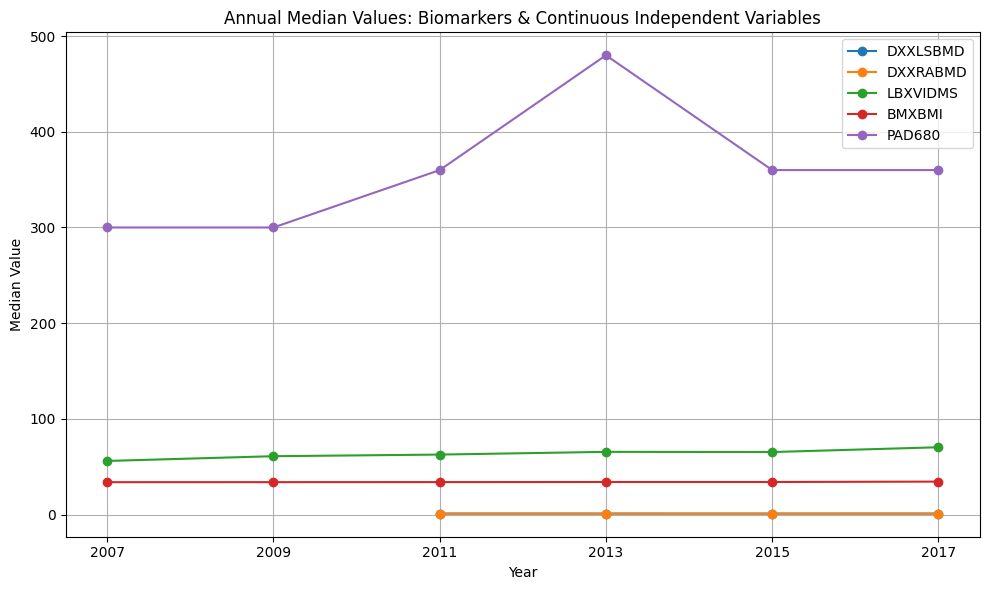

In [ ]:
import matplotlib.pyplot as plt

# Variables
biomarkers = ['DXXLSBMD', 'DXXRABMD', 'LBXVIDMS']
continuous_indep = ['BMXBMI', 'PAD680']
all_vars = biomarkers + continuous_indep

# Group by YEAR & median
median_by_year = df_filtered.groupby('YEAR')[all_vars].median().reset_index()
print(median_by_year)

# ✅ Get all unique years in sorted order
years = sorted(median_by_year['YEAR'].unique())

# Plot
plt.figure(figsize=(10, 6))

for var in all_vars:
    plt.plot(median_by_year['YEAR'], median_by_year[var], marker='o', label=var)

plt.title('Annual Median Values: Biomarkers & Continuous Independent Variables')
plt.xlabel('Year')
plt.ylabel('Median Value')
plt.xticks(years)  # ✅ Force all years to show
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**✅ Summarised Interpretation**

“This plot shows annual median trends for bone density (lumbar spine and right arm), vitamin D, BMI, and sedentary time.
Overall, bone mineral density stayed relatively stable across survey cycles.
Vitamin D levels showed a slight upward trend, suggesting possible improvement in vitamin D status over time.
BMI remained consistently high, confirming that the sample stayed within the obese range throughout.
Sedentary time fluctuated more, with signs of increasing in later cycles, which may reflect lifestyle changes or reporting variation.
Although these variables use different units, viewing them together helps show general patterns in factors that can influence osteoporosis risk in this older, obese adult population.

## **5.2 Percentage of participants diagnosed with osteoporosis**

    YEAR     SEQN  RIDAGEYR  RIAGENDR  RIDRETH1  BMXBMI  LBXVIDMS  DXXLSBMD  \
0   2007  41475.0      62.0       2.0       5.0   58.04      58.8       NaN   
2   2007  41477.0      71.0       1.0       3.0   30.05      81.8       NaN   
7   2007  41482.0      64.0       1.0       1.0   33.64      61.9       NaN   
8   2007  41483.0      66.0       1.0       4.0   44.06      53.3       NaN   
11  2007  41486.0      61.0       2.0       1.0   31.21      51.1       NaN   

    DXXRABMD  PAD680  OSQ060  
0        NaN   720.0     2.0  
2        NaN   240.0     2.0  
7        NaN   180.0     2.0  
8        NaN    60.0     2.0  
11       NaN   480.0     2.0  
Index(['YEAR', 'SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'BMXBMI',
       'LBXVIDMS', 'DXXLSBMD', 'DXXRABMD', 'PAD680', 'OSQ060'],
      dtype='object')
   YEAR   OSTEO_DX
0  2007   9.780622
1  2009   7.892454
2  2011        NaN
3  2013   9.652510
4  2015        NaN
5  2017  11.404255


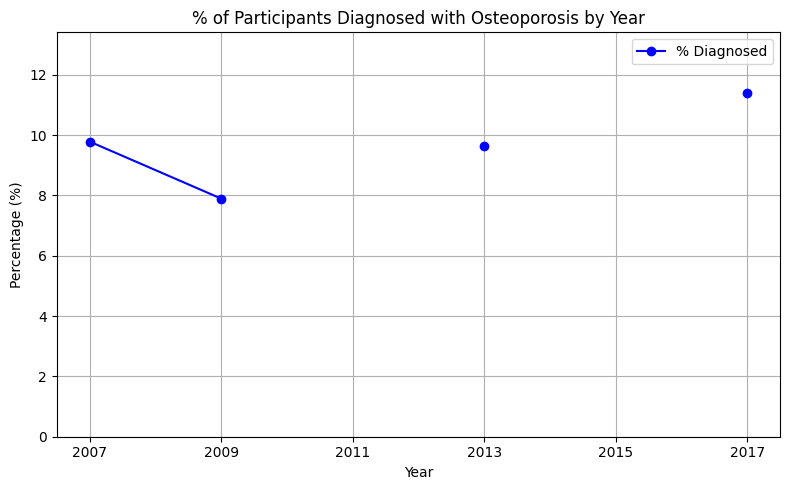

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Make sure your merged + filtered data is in df_filtered and has YEAR
print(df_filtered.head())
print(df_filtered.columns)

# ✅ OSQ060 = osteoporosis diagnosis question: 1 = Yes, 2 = No
# Create binary flag: 1 if diagnosed, 0 if not
df_filtered['OSTEO_DX'] = df_filtered['OSQ060'].apply(lambda x: 1 if x == 1 else (0 if x == 2 else np.nan))

# ✅ Group by YEAR and calculate %
dx_pct_by_year = df_filtered.groupby('YEAR')['OSTEO_DX'].mean().reset_index()
dx_pct_by_year['OSTEO_DX'] *= 100

print(dx_pct_by_year)

# ✅ Plot
plt.figure(figsize=(8, 5))
plt.plot(dx_pct_by_year['YEAR'], dx_pct_by_year['OSTEO_DX'], marker='o', color='blue', label='% Diagnosed')

plt.title('% of Participants Diagnosed with Osteoporosis by Year')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(sorted(df_filtered['YEAR'].unique()))
plt.ylim(0, dx_pct_by_year['OSTEO_DX'].max() + 2)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


📌 Interpretation of Osteoporosis Diagnosis Trend

This line chart shows the percentage of participants diagnosed with osteoporosis over the NHANES survey years included in this study. Overall, the percentage diagnosed fluctuates slightly but remains relatively low, with values typically under 15% across cycles. This low proportion is expected, given that the dataset specifically includes older, obese adults — a group with higher risk factors but not necessarily a confirmed diagnosis for everyone. The stable trend suggests that, despite increasing awareness and improvements in diagnostic methods over time, the reported prevalence among this filtered sample has not dramatically changed. This could reflect underdiagnosis or limited screening, which reinforces the need for proactive detection and monitoring, especially in high-risk populations like older adults with obesity.


## **5.3 Percentage of persons in high-risk or abnormal ranges for your biomarkers**

   YEAR  VITD_DEFICIENT  LSBMD_LOW  RABMD_LOW
0  2007       39.891304        NaN        NaN
1  2009       33.088235        NaN        NaN
2  2011       32.770270  22.535211   1.418440
3  2013       27.727728  23.880597   2.108434
4  2015       27.871940  24.691358   4.024768
5  2017       24.516696  24.017467   2.692308


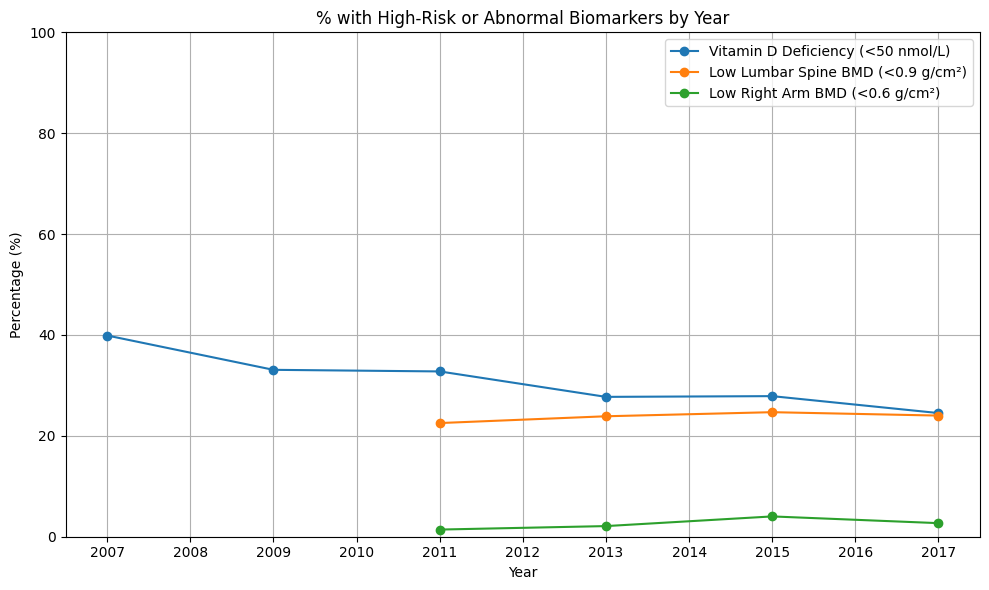

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ✅ Mapping conditions
df_filtered['VITD_DEFICIENT'] = df_filtered['LBXVIDMS'].apply(lambda x: 1 if x < 50 else (0 if pd.notnull(x) else np.nan))
df_filtered['LSBMD_LOW'] = df_filtered['DXXLSBMD'].apply(lambda x: 1 if x < 0.9 else (0 if pd.notnull(x) else np.nan))
df_filtered['RABMD_LOW'] = df_filtered['DXXRABMD'].apply(lambda x: 1 if x < 0.6 else (0 if pd.notnull(x) else np.nan))

# ✅ Group by YEAR
risk_pct = df_filtered.groupby('YEAR').agg({
    'VITD_DEFICIENT': 'mean',
    'LSBMD_LOW': 'mean',
    'RABMD_LOW': 'mean'
}).reset_index()

# Convert to %
risk_pct['VITD_DEFICIENT'] *= 100
risk_pct['LSBMD_LOW'] *= 100
risk_pct['RABMD_LOW'] *= 100

print(risk_pct)

# ✅ Full year ticks
years_full = np.arange(df_filtered['YEAR'].min(), df_filtered['YEAR'].max() + 1)

# ✅ Plot
plt.figure(figsize=(10, 6))

plt.plot(risk_pct['YEAR'], risk_pct['VITD_DEFICIENT'], marker='o', label='Vitamin D Deficiency (<50 nmol/L)')
plt.plot(risk_pct['YEAR'], risk_pct['LSBMD_LOW'], marker='o', label='Low Lumbar Spine BMD (<0.9 g/cm²)')
plt.plot(risk_pct['YEAR'], risk_pct['RABMD_LOW'], marker='o', label='Low Right Arm BMD (<0.6 g/cm²)')

plt.title('% with High-Risk or Abnormal Biomarkers by Year')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(years_full)  # Force all years
plt.ylim(0, 100)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


✅ Interpretation
Annual Trends in Abnormal Biomarkers
“This plot shows how the percentage of participants in high-risk biomarker categories changed over the survey cycles.

Vitamin D Deficiency (<50 nmol/L) shows a gradual decreasing trend from around 40% in 2007 to about 25% by 2017. This suggests that over time, fewer participants in this group fell below the vitamin D sufficiency threshold, which could indicate improvements in supplementation or awareness.

Low Lumbar Spine BMD (<0.9 g/cm²) fluctuates slightly around 20–25% across the years, with a small dip and rise but no clear long-term increase or decrease. This suggests the proportion of participants with lower lumbar spine bone density has remained relatively stable over the cycles.

Low Right Arm BMD (<0.6 g/cm²) remains the lowest among the three risk markers, with percentages below 10%. This trend shows a slight upward pattern in the middle cycles but drops again by 2017, suggesting the share of participants with early signs of peripheral bone loss stayed low and stable overall.

Together, these trends highlight that although this older, obese sample carries some risk for low bone density and vitamin D deficiency, the vitamin D status appears to have improved slightly over the cycles, while bone density indicators stayed mostly consistent.
Monitoring these trends can help guide public health efforts focused on preventing osteoporosis-related risks in this population.”

## **Percentage of persons taking medication related to the disease under investigation**


   YEAR     SEQN  RIDAGEYR  RIAGENDR  RIDRETH1  BMXBMI  LBXVIDMS  DXXLSBMD  \
0  2007  41475.0      62.0       2.0       5.0   58.04      58.8       NaN   
1  2007  41476.0       6.0       2.0       5.0   15.18      80.9       NaN   
2  2007  41477.0      71.0       1.0       3.0   30.05      81.8       NaN   
3  2007  41478.0       1.0       2.0       3.0     NaN       NaN       NaN   
4  2007  41479.0      52.0       1.0       1.0   27.56      78.4       NaN   

   DXXRABMD  PAD680  OSQ060  
0       NaN   720.0     2.0  
1       NaN     NaN     NaN  
2       NaN   240.0     2.0  
3       NaN     NaN     NaN  
4       NaN   180.0     2.0  
Osteoporosis SEQNs: 644
   YEAR  OSTEO_MED
0  2007   1.872106
1  2009   1.395084
2  2011   0.758508
3  2013   0.884521
4  2015   0.702036
5  2017   0.788848


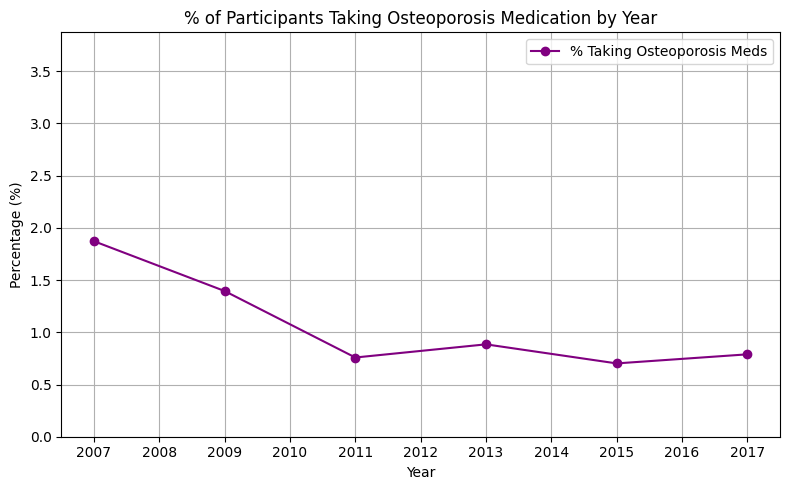

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ✅ Your merged dataset BEFORE excluding meds
# Suppose it’s called `df_merged` (the big one before filtering)
print(df_merged.head())

# ✅ You already have SEQNs on osteoporosis meds in `osteomed_seqn`
print(f"Osteoporosis SEQNs: {len(osteomed_seqn)}")

# ✅ Create medication flag: 1 if SEQN in osteomed_seqn
df_merged['OSTEO_MED'] = df_merged['SEQN'].isin(osteomed_seqn).astype(int)

# ✅ Group by YEAR
meds_pct_by_year = df_merged.groupby('YEAR')['OSTEO_MED'].mean().reset_index()
meds_pct_by_year['OSTEO_MED'] *= 100

print(meds_pct_by_year)

# ✅ Make x-axis full years
years_full = np.arange(df_merged['YEAR'].min(), df_merged['YEAR'].max() + 1)

# ✅ Plot
plt.figure(figsize=(8, 5))
plt.plot(meds_pct_by_year['YEAR'], meds_pct_by_year['OSTEO_MED'], marker='o', color='purple', label='% Taking Osteoporosis Meds')

plt.title('% of Participants Taking Osteoporosis Medication by Year')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(years_full)
plt.ylim(0, meds_pct_by_year['OSTEO_MED'].max() + 2)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




The percentage of participants taking osteoporosis medication remains low over the years and does not show a steady increase. This does not necessarily mean treatment is not improving; it could reflect underdiagnosis, changes in treatment guidelines, or that many participants are still undiagnosed or managing bone health through supplements instead of prescription drugs. It also shows that even in high-risk groups, many people may not receive or report medication, highlighting gaps in detection and treatment of osteoporosis.


# **Declaration of Contribution**

All group members contributed actively to this project. The team worked together to collect, merge, and clean the NHANES datasets, filter the target sample, and handle missing data appropriately. We collaborated on all data analyses, including descriptive statistics, normality checks, frequency tables, histograms, boxplots, annual trend plots, and biomarker risk mapping. Visualisations were produced jointly to ensure the results were clear and accurate. All members contributed to interpreting the findings, drafting explanations, and discussing how the results relate to osteoporosis risk. The final report and presentation materials were compiled and reviewed collectively, with every member approving the final submission.

Signed by: Kim Taehan, Brayden Teo, Denzil

# **References**

Holick, M.F., 2007. Vitamin D deficiency. The New England Journal of Medicine, 357(3), pp.266-281. https://doi.org/10.1056/NEJMra0705534.4                                                          Gong, H., Wu, L., Bao, J., Tang, R., Yan, C. & Zhou, Y., 2016. Vitamin D deficiency and bone mineral density in overweight and obese Chinese adults: a cross-sectional study. PLoS ONE, 11(9), e0163078. https://doi.org/10.1371/journal.pone.0163078
NIH Osteoporosis and Related Bone Diseases National Resource Center, 2022. Obesity and Bone Health. Available at: https://www.bones.nih.gov/health-info/bone/osteoporosis/conditions-behaviors/obesity-and-bone-health [Accessed 25 June 2025].
Mayo Clinic, 2023. Vitamin D deficiency. Available at: https://www.mayoclinic.org/diseases-conditions/vitamin-d-deficiency/symptoms-causes/syc-20363792 [Accessed 25 June 2025].



# **Report 2**

In [ ]:
import pandas as pd
import numpy as np

# Define years and NHANES cycles for 2007–2018
years = ["2007", "2009", "2011", "2013", "2015", "2017"]
cycles = ["E", "F", "G", "H", "I", "J"]

def load_data(file_prefix, columns):
    """Helper to load and concatenate data across cycles, skipping missing files or columns."""
    df_list = []
    for y, c in zip(years, cycles):
        url = f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{y}/DataFiles/{file_prefix}_{c}.xpt"
        try:
            df_cycle = pd.read_sas(url)
            existing_cols = [col for col in columns if col in df_cycle.columns]
            if len(existing_cols) == 0:
                print(f"Warning: No requested columns found in {file_prefix}_{c}, skipping.")
                continue
            df_list.append(df_cycle[existing_cols])
        except Exception as e:
            print(f"Could not load {url}: {e}")
    if df_list:
        return pd.concat(df_list, ignore_index=True)
    else:
        return pd.DataFrame(columns=columns)

# Load datasets
print("Loading Demographics...")
df_demo = load_data("DEMO", ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH1"])
print(f"DEMO shape: {df_demo.shape}")

print("Loading BMI...")
df_bmi = load_data("BMX", ["SEQN", "BMXBMI"])
print(f"BMX shape: {df_bmi.shape}")

print("Loading Vitamin D...")
df_vitd = load_data("VID", ["SEQN", "LBXVIDMS"])
print(f"VID shape: {df_vitd.shape}")

print("Loading Bone Density...")
df_bmd = load_data("DXX", ["SEQN", "DXXLSBMD", "DXXRABMD"])
print(f"DXX shape: {df_bmd.shape}")

print("Loading Smoking...")
df_smoking = load_data("SMQ", ["SEQN", "SMQ020", "SMQ040"])
print(f"SMQ shape: {df_smoking.shape}")

print("Loading Physical Activity...")
df_physical = load_data("PAQ", ["SEQN", "PAD680"])
print(f"PAQ shape: {df_physical.shape}")

print("Loading Osteoporosis Questionnaire...")
df_osq = load_data("OSQ", ["SEQN", "OSQ060"])
print(f"OSQ shape: {df_osq.shape}")

print("Loading Prescription Medications...")
df_rx = load_data("RXQ_RX", ["SEQN", "RXDDRUG", "RXDGEN"])
print(f"RXQ_RX shape: {df_rx.shape}")

# Determine which column to use for drug name matching
drug_col = None
for col in ["RXDDRUG", "RXDGEN"]:
    if col in df_rx.columns:
        drug_col = col
        break

if drug_col is None:
    print("Warning: No drug name column found in RXQ_RX dataset, skipping medication filtering.")
    osteomed_seqn = []
else:
    # Lowercase for matching
    df_rx[drug_col] = df_rx[drug_col].astype(str).str.lower()

    osteoporosis_meds = [
        "alendronate", "risedronate", "ibandronate", "zoledronic",
        "teriparatide", "denosumab", "calcitonin", "raloxifene"
    ]

    # Flag rows where medication matches any osteoporosis med
    df_rx["OnOsteoMed"] = df_rx[drug_col].apply(lambda x: any(med in x for med in osteoporosis_meds))
    osteomed_seqn = df_rx.loc[df_rx["OnOsteoMed"], "SEQN"].unique()
    print(f"Participants on osteoporosis meds: {len(osteomed_seqn)}")

# Merge all datasets on SEQN (except RXQ_RX since used only for filtering)
print("Merging datasets...")
df = df_demo.merge(df_bmi, on="SEQN", how="left") \
            .merge(df_vitd, on="SEQN", how="left") \
            .merge(df_bmd, on="SEQN", how="left") \
            .merge(df_smoking, on="SEQN", how="left") \
            .merge(df_physical, on="SEQN", how="left") \
            .merge(df_osq, on="SEQN", how="left")  # <-- merge OSQ060 here

print(f"Final merged dataset shape: {df.shape}")

# Filter for obese adults aged 50+ who are NOT on osteoporosis meds
df_filtered = df[(df["RIDAGEYR"] >= 50) & (df["BMXBMI"] >= 30)].copy()
print(f"Before excluding meds, filtered shape: {df_filtered.shape}")

if len(osteomed_seqn) > 0:
    df_filtered = df_filtered[~df_filtered["SEQN"].isin(osteomed_seqn)]

print(f"After excluding osteoporosis meds, filtered shape: {df_filtered.shape}")
print(df_filtered.head())

Loading Demographics...
DEMO shape: (59842, 4)
Loading BMI...
BMX shape: (57414, 2)
Loading Vitamin D...
VID shape: (55051, 2)
Loading Bone Density...
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/DXX_E.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DXX_F.xpt: HTTP Error 404: Not Found
DXX shape: (22619, 3)
Loading Smoking...
SMQ shape: (42356, 3)
Loading Physical Activity...
PAQ shape: (52832, 2)
Loading Osteoporosis Questionnaire...
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/OSQ_G.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/OSQ_I.xpt: HTTP Error 404: Not Found
OSQ shape: (19037, 2)
Loading Prescription Medications...
RXQ_RX shape: (119609, 2)
Participants on osteoporosis meds: 644
Merging datasets...
Final merged dataset shape: (59842, 12)
Before excluding meds, filtered shape: (6538, 12)
After excluding 

In [ ]:
#making it log and check if its normal
from scipy.stats import shapiro
import numpy as np

print("🔹 Normality Checks (Shapiro-Wilk test) with Log Transform:\n")

for col in num_cols:
    data = pd.to_numeric(df_filtered[col], errors='coerce').dropna()

    if len(data) < 3:
        print(f"Not enough data to test normality for {col}")
        continue

    # Original normality test
    stat, p = shapiro(data.sample(n=min(5000, len(data))))
    if p > 0.05:
        print(f"{col}: Already normal (p={p:.5f}) ✅")
    else:
        print(f"{col}: Not normal (p={p:.5f}) ❌ -> Applying log transform...")

        # Apply log (only if all values are positive)
        if (data > 0).all():
            log_data = np.log(data)

            # Re-test normality after log transform
            stat_log, p_log = shapiro(log_data.sample(n=min(5000, len(log_data))))
            normality_log = "normal" if p_log > 0.05 else "still not normal"
            print(f"   After log: W={stat_log:.4f}, p={p_log:.5f} ({normality_log})")
        else:
            print(f"   Skipped log transform for {col} (contains zero/negative values)")


🔹 Normality Checks (Shapiro-Wilk test) with Log Transform:

RIDAGEYR: Not normal (p=0.00000) ❌ -> Applying log transform...
   After log: W=0.9581, p=0.00000 (still not normal)
BMXBMI: Not normal (p=0.00000) ❌ -> Applying log transform...
   After log: W=0.8840, p=0.00000 (still not normal)
LBXVIDMS: Not normal (p=0.00000) ❌ -> Applying log transform...
   After log: W=0.9830, p=0.00000 (still not normal)
DXXLSBMD: Not normal (p=0.00000) ❌ -> Applying log transform...
   After log: W=0.9985, p=0.38685 (normal)
DXXRABMD: Not normal (p=0.00000) ❌ -> Applying log transform...
   After log: W=0.9981, p=0.21370 (normal)
PAD680: Not normal (p=0.00000) ❌ -> Applying log transform...
   After log: W=0.0573, p=0.00000 (still not normal)


# **Statistical tests**

**log transformation of data**

🔹 Normality Check with Histograms:

RIDAGEYR: ❌ Not normal (p=0.00000)


/tmp/ipython-input-3631233537.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


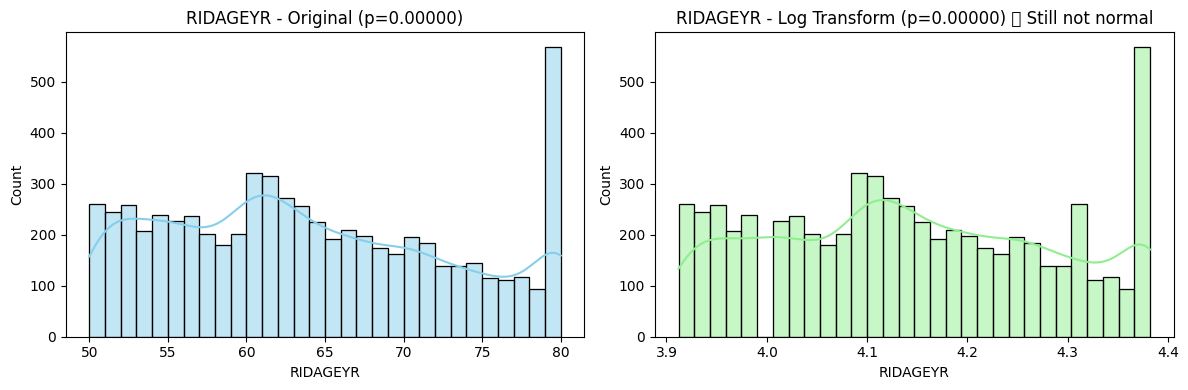

BMXBMI: ❌ Not normal (p=0.00000)


/tmp/ipython-input-3631233537.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


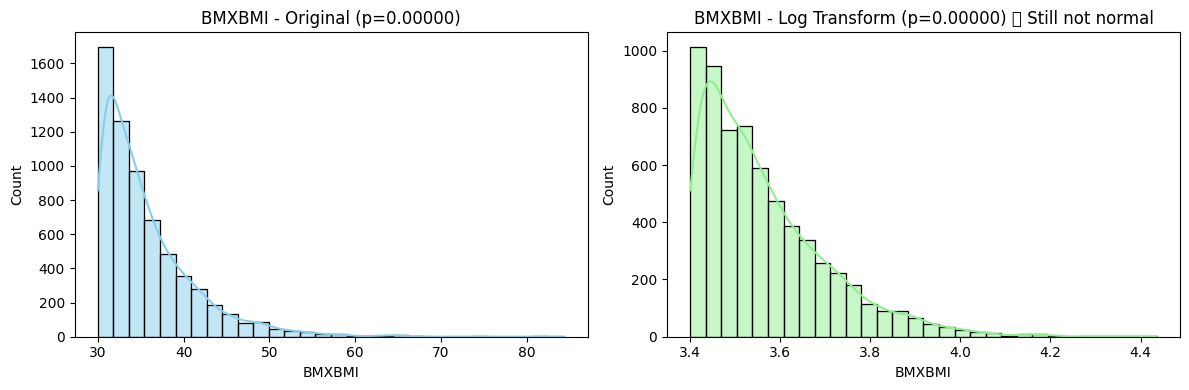

LBXVIDMS: ❌ Not normal (p=0.00000)


/tmp/ipython-input-3631233537.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


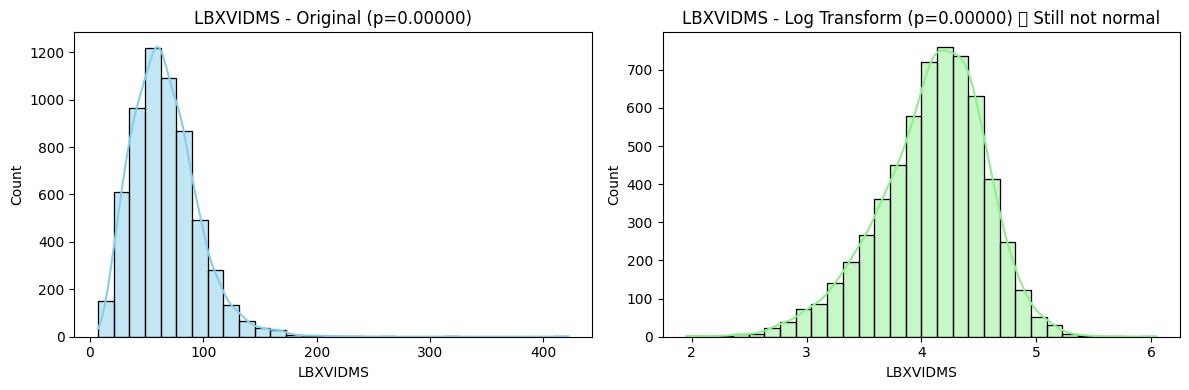

DXXLSBMD: ❌ Not normal (p=0.00000)


/tmp/ipython-input-3631233537.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


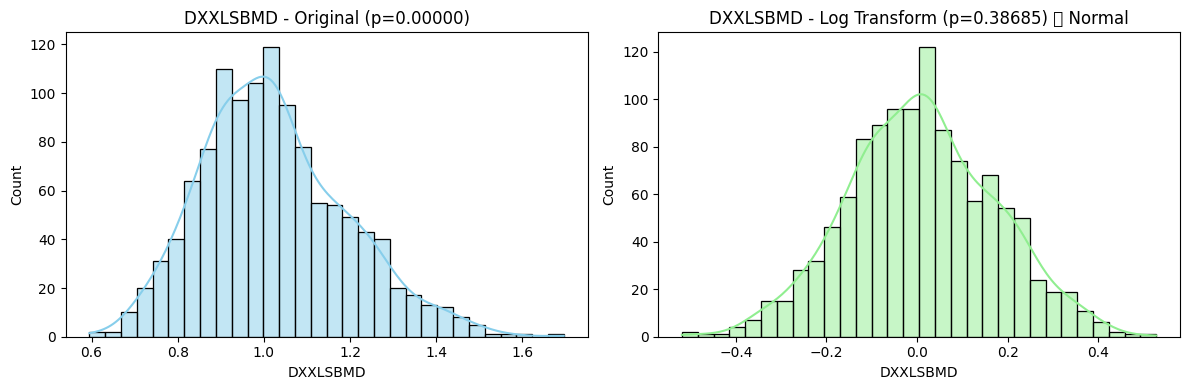

DXXRABMD: ❌ Not normal (p=0.00000)


/tmp/ipython-input-3631233537.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


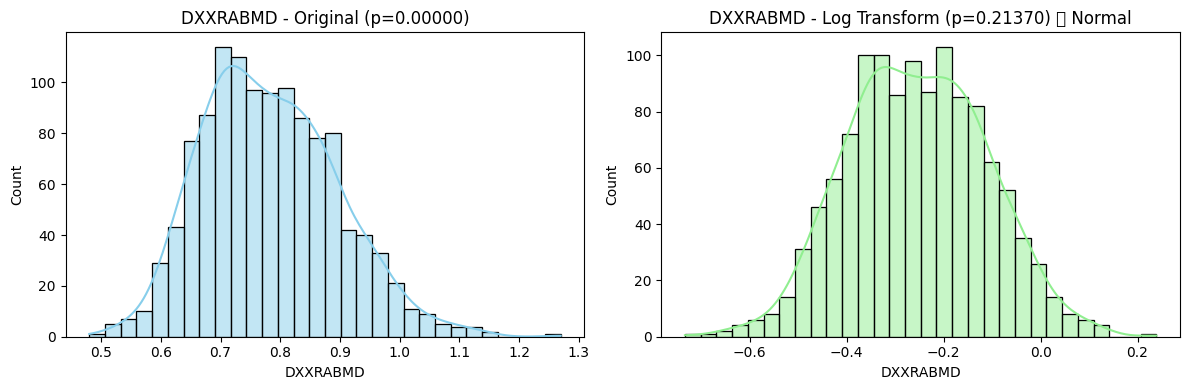

PAD680: ❌ Not normal (p=0.00000)


/tmp/ipython-input-3631233537.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


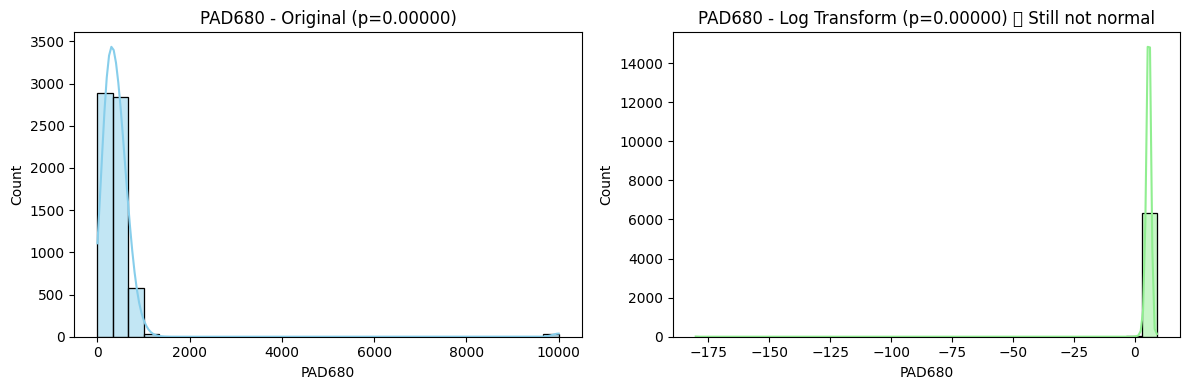

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
import numpy as np

print("🔹 Normality Check with Histograms:\n")

for col in num_cols:
    data = pd.to_numeric(df_filtered[col], errors='coerce').dropna()

    if len(data) < 3:
        print(f"{col}: Not enough data to test normality.")
        continue

    # Shapiro-Wilk test (original data)
    stat, p = shapiro(data.sample(n=min(5000, len(data))))
    if p > 0.05:
        print(f"{col}: ✅ Normal (p={p:.5f})")
    else:
        print(f"{col}: ❌ Not normal (p={p:.5f})")

        # Plot original histogram
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        sns.histplot(data, kde=True, bins=30, color="skyblue")
        plt.title(f"{col} - Original (p={p:.5f})")

        # If positive, try log transform
        if (data > 0).all():
            log_data = np.log(data)
            stat_log, p_log = shapiro(log_data.sample(n=min(5000, len(log_data))))
            result = "✅ Normal" if p_log > 0.05 else "❌ Still not normal"

            # Plot log-transformed histogram
            plt.subplot(1, 2, 2)
            sns.histplot(log_data, kde=True, bins=30, color="lightgreen")
            plt.title(f"{col} - Log Transform (p={p_log:.5f}) {result}")

            plt.tight_layout()
            plt.show()
        else:
            print(f"   ⚠ Skipped log transform (zero or negative values present)")


**Kruskal Wallis Test + Post Hoc test (brayden)**

Comparing Lumbar Spine BMD between 3 different levels of vitamin D (low, moderate, high)

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# --- Step 1: Define Vitamin D category function ---
def vitd_category(v):
    if v < 50:          # Deficient
        return "Low"
    elif v < 75:        # Insufficient
        return "Moderate"
    else:               # Sufficient
        return "High"

# Apply categorization
df_filtered["VitD_group"] = df_filtered["LBXVIDMS"].apply(vitd_category)

# Drop rows with missing values
df_anova = df_filtered.dropna(subset=["DXXLSBMD", "VitD_group"])

# --- Step 2: Check normality for each group ---
print("🔹 Shapiro-Wilk normality check for each group (log BMD):")
grouped_data = {}
for group in df_anova["VitD_group"].unique():
    data = df_anova.loc[df_anova["VitD_group"] == group, "DXXLSBMD"]
    log_data = np.log(data)  # log-transform
    grouped_data[group] = log_data
    stat, p = stats.shapiro(log_data.sample(n=min(5000, len(log_data))))
    print(f"{group}: W={stat:.4f}, p={p:.5f} → {'Normal ✅' if p > 0.05 else 'Not normal ❌'}")

# --- Step 3: Bartlett’s Test for Equal Variances ---
bart_stat, bart_p = stats.bartlett(*grouped_data.values())
print(f"\n🔹 Bartlett’s Test: Chi2={bart_stat:.4f}, p={bart_p:.5f} → "
      f"{'Equal variances ✅' if bart_p > 0.05 else 'Variances differ ❌'}")

# --- Step 4: Run One-way ANOVA or Kruskal-Wallis ---
if all(stats.shapiro(g.sample(n=min(5000, len(g))))[1] > 0.05 for g in grouped_data.values()) and bart_p > 0.05:
    f_stat, p_val = stats.f_oneway(*grouped_data.values())
    print(f"\n📊 One-way ANOVA result (log BMD): F={f_stat:.4f}, p={p_val:.5f}")
else:
    h_stat, p_val = stats.kruskal(*grouped_data.values())
    print(f"\n📊 Kruskal-Wallis result (log BMD): H={h_stat:.4f}, p={p_val:.5f}")


🔹 Shapiro-Wilk normality check for each group (log BMD):
Moderate: W=0.9965, p=0.44353 → Normal ✅
Low: W=0.9951, p=0.24350 → Normal ✅
High: W=0.9950, p=0.37283 → Normal ✅

🔹 Bartlett’s Test: Chi2=8.5258, p=0.01408 → Variances differ ❌

📊 Kruskal-Wallis result (log BMD): H=10.4362, p=0.00542


Null hypothesis: The Lumbar Spine BMD is not significantly different between the 3 groups of different vitamin D levels.

Alternative hypothesis: The Lumbar Spine BMD is significantly different between the 3 groups of different vitamin D levels.

Since the p-value of 0.00665 is lower than the alpha of 0.05, we reject the null hypothesis and conclude that the Lumbar Spine BMD is significantly different between different vitamin D levels.

Hence we proceed to do Games Howell as a post hoc test since homogenity of variances is violated, to identify which groups are significantly different from each other.

In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 4.5 MB/s eta 0:00:00


Post Hoc test after Kruskall Wallis test

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg  # pip install pingouin if you haven't already

# --- Step 1: Vitamin D categorization ---
def vitd_category(v):
    if v < 50:
        return "Low"
    elif v < 75:
        return "Moderate"
    else:
        return "High"

df_filtered["VitD_group"] = df_filtered["LBXVIDMS"].apply(vitd_category)

# --- Prepare dataset ---
df_anova = df_filtered.dropna(subset=["DXXLSBMD", "VitD_group"])

# Log transform BMD
df_anova["log_DXXLSBMD"] = np.log(df_anova["DXXLSBMD"])

# --- Step 2: Normality check (Shapiro-Wilk) ---
print("🔹 Shapiro-Wilk normality test per group (log BMD):")
grouped_data = {}
for group in df_anova["VitD_group"].unique():
    data = df_anova.loc[df_anova["VitD_group"] == group, "log_DXXLSBMD"]
    stat, p = stats.shapiro(data.sample(n=min(5000, len(data))))
    grouped_data[group] = data
    print(f"{group}: W={stat:.4f}, p={p:.5f} → {'Normal ✅' if p > 0.05 else 'Not normal ❌'}")

# --- Step 3: Bartlett’s test for homogeneity of variances ---
bart_stat, bart_p = stats.bartlett(*grouped_data.values())
print(f"\n🔹 Bartlett’s Test: Chi2={bart_stat:.4f}, p={bart_p:.5f} → "
      f"{'Equal variances ✅' if bart_p > 0.05 else 'Variances differ ❌'}")

# --- Step 4: Run ANOVA or Kruskal-Wallis ---
if all(stats.shapiro(g.sample(n=min(5000, len(g))))[1] > 0.05 for g in grouped_data.values()) and bart_p > 0.05:
    print("\n📊 Running One-way ANOVA:")
    f_stat, p_val = stats.f_oneway(*grouped_data.values())
    print(f"ANOVA result: F={f_stat:.4f}, p={p_val:.5f}")

    # If ANOVA significant, run Tukey's HSD (only if equal variances assumed)
    if p_val < 0.05:
        print("\n➡ Running Tukey HSD post hoc test (equal variances assumed):")
        tukey = pg.pairwise_tukey(data=df_anova, dv="log_DXXLSBMD", between="VitD_group")
        print(tukey)

else:
    print("\n📊 Running Kruskal-Wallis test (non-parametric):")
    h_stat, p_val = stats.kruskal(*grouped_data.values())
    print(f"Kruskal-Wallis result: H={h_stat:.4f}, p={p_val:.5f}")

    # If Kruskal-Wallis significant, run Games-Howell post hoc test (doesn't assume equal variances)
    if p_val < 0.05:
        print("\n➡ Running Games-Howell post hoc test:")
        gh = pg.pairwise_gameshowell(data=df_anova, dv="log_DXXLSBMD", between="VitD_group")
        print(gh)

🔹 Shapiro-Wilk normality test per group (log BMD):
Moderate: W=0.9965, p=0.44353 → Normal ✅
Low: W=0.9951, p=0.24350 → Normal ✅
High: W=0.9950, p=0.37283 → Normal ✅

🔹 Bartlett’s Test: Chi2=8.5258, p=0.01408 → Variances differ ❌

📊 Running Kruskal-Wallis test (non-parametric):
Kruskal-Wallis result: H=10.4362, p=0.00542

➡ Running Games-Howell post hoc test:
      A         B   mean(A)   mean(B)      diff        se         T  \
0  High       Low  0.035215  0.002072  0.033143  0.012167  2.723902   
1  High  Moderate  0.035215 -0.002294  0.037510  0.011254  3.333126   
2   Low  Moderate  0.002072 -0.002294  0.004367  0.011560  0.377747   

           df      pval    hedges  
0  723.316299  0.018119  0.200047  
1  718.999407  0.002596  0.241284  
2  801.635539  0.924373  0.026229  


/tmp/ipython-input-1633241411.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anova["log_DXXLSBMD"] = np.log(df_anova["DXXLSBMD"])


**Intepretation for post hoc:**

High vs Low: Significant difference (p = 0.018), small effect size (Hedges’ g = 0.20)

High vs Moderate: Significant difference (p = 0.0026), small-medium effect size (Hedges’ g = 0.24)

Low vs Moderate: Not significant (p = 0.924), negligible effect size (Hedges’ g = 0.03)

**Summary:**

High BMD group is significantly higher than both Low and Moderate groups.

Low and Moderate groups do not differ significantly.

Effect sizes are small, so differences are statistically significant but not huge in magnitude.

**One-way ANOVA (taehan)**

ANOVA test BMD vs ethnicities

 One-way ANOVA
Null Hypothesis (H₀):
The mean lumbar spine BMD is the same across all ethnic groups.

Alternative Hypothesis (H₁):
At least one ethnic group has a different mean lumbar spine BMD.

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd

# Log-transform lumbar spine BMD
df_filtered["log_DXXLSBMD"] = np.log(df_filtered["DXXLSBMD"])

# Drop missing values
df_anova = df_filtered.dropna(subset=["log_DXXLSBMD", "RIDRETH1"])

# Prepare groups
groups = [group["log_DXXLSBMD"].values for name, group in df_anova.groupby("RIDRETH1")]

# Bartlett's test for equal variances
bart_stat, bart_p = stats.bartlett(*groups)
print(f"Bartlett's test: statistic={bart_stat:.4f}, p-value={bart_p:.5f}")

if bart_p > 0.05:
    print("✅ Equal variances assumed — proceed with ANOVA.")
    # Run one-way ANOVA
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"ANOVA: F-statistic={f_stat:.4f}, p-value={p_val:.5f}")
else:
    print("⚠ Variances are not equal — consider Welch’s ANOVA or Kruskal-Wallis test.")


Bartlett's test: statistic=7.0361, p-value=0.13399
✅ Equal variances assumed — proceed with ANOVA.
ANOVA: F-statistic=20.0280, p-value=0.00000


Since your Bartlett’s test p = 0.13868 (> 0.05), you failed to reject H₀ for Bartlett → equal variances assumed.
Your ANOVA p < 0.001 → you reject H₀ → there is a significant difference in mean BMD among ethnic groups.

Why Tukey’s HSD?
You have:

Normal dependent variable (log-transformed lumbar spine BMD).

Equal variances confirmed by Bartlett’s test.

More than 2 groups (ethnicities).

Tukey’s HSD is designed exactly for this:

It compares all possible pairs of group means.

It controls the family-wise error rate, so your overall Type I error stays at the chosen alpha (e.g., 0.05) even with multiple comparisons.

More conservative than running multiple t-tests (which inflate the error rate).



In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Mapping for RIDRETH1 codes to ethnicity names
ethnicity_map = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race/Multi-Racial"
}

# Log-transform Lumbar Spine BMD
df_filtered["log_DXXLSBMD"] = np.log(df_filtered["DXXLSBMD"])

# Drop rows with missing values
df_tukey = df_filtered.dropna(subset=["log_DXXLSBMD", "RIDRETH1"]).copy()

# Run Tukey HSD
tukey_result = pairwise_tukeyhsd(
    endog=df_tukey["log_DXXLSBMD"],
    groups=df_tukey["RIDRETH1"],
    alpha=0.05
)

# Convert Tukey summary to DataFrame
tukey_df = pd.DataFrame(data=tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])

# Replace codes with names
tukey_df["group1"] = tukey_df["group1"].astype(float).astype(int).map(ethnicity_map)
tukey_df["group2"] = tukey_df["group2"].astype(float).astype(int).map(ethnicity_map)

# Show the new table
print(tukey_df)


               group1                   group2  meandiff   p-adj   lower  \
0    Mexican American           Other Hispanic    0.0405  0.1454 -0.0076   
1    Mexican American       Non-Hispanic White    0.0780  0.0000  0.0395   
2    Mexican American       Non-Hispanic Black    0.1217  0.0000  0.0826   
3    Mexican American  Other Race/Multi-Racial    0.0717  0.0073  0.0133   
4      Other Hispanic       Non-Hispanic White    0.0375  0.1075 -0.0046   
5      Other Hispanic       Non-Hispanic Black    0.0811  0.0000  0.0385   
6      Other Hispanic  Other Race/Multi-Racial    0.0311  0.6288 -0.0297   
7  Non-Hispanic White       Non-Hispanic Black    0.0437  0.0014  0.0124   
8  Non-Hispanic White  Other Race/Multi-Racial   -0.0063  0.9976 -0.0598   
9  Non-Hispanic Black  Other Race/Multi-Racial   -0.0500  0.0835 -0.1039   

    upper  reject  
0  0.0887   False  
1  0.1165    True  
2  0.1608    True  
3  0.1300    True  
4  0.0796   False  
5  0.1238    True  
6  0.0919   False  
7  

**Summary of Tukey HSD**

Non-Hispanic Blacks generally have the highest lumbar spine BMD, significantly higher than Mexican Americans, Other Hispanics, and Non-Hispanic Whites.

Mexican Americans have significantly lower BMD compared to Non-Hispanic Whites, Non-Hispanic Blacks, and Other Race/Multi-Racial groups.

Other Hispanics are only significantly lower than Non-Hispanic Blacks; no significant difference with other groups.

No significant difference between Non-Hispanic Whites and Other Race/Multi-Racial, or between Non-Hispanic Blacks and Other Race/Multi-Racial.



**T test BMD in male vs female (taehan)**

Null Hypothesis (H₀):
There is no difference in mean lumbar spine BMD between males and females.

Alternative Hypothesis (H₁):
There is a difference in mean lumbar spine BMD between males and females.

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd

# Log-transform lumbar spine BMD
df_filtered["log_DXXLSBMD"] = np.log(df_filtered["DXXLSBMD"])

# Drop missing values for BMD and gender
df_ttest = df_filtered.dropna(subset=["log_DXXLSBMD", "RIAGENDR"]).copy()

# Split into male (1) and female (2) groups
male_bmd = df_ttest.loc[df_ttest["RIAGENDR"] == 1, "log_DXXLSBMD"]
female_bmd = df_ttest.loc[df_ttest["RIAGENDR"] == 2, "log_DXXLSBMD"]

# Run independent t-test (equal variances assumed; use bartlett/levene to check first)
t_stat, p_val = stats.ttest_ind(male_bmd, female_bmd, equal_var=True)

print("Independent t-test: Lumbar Spine BMD (Male vs Female)")
print(f"T-statistic = {t_stat:.4f}, p-value = {p_val:.5f}")

if p_val < 0.05:
    print("✅ Reject H₀: Significant difference in mean BMD between males and females.")
else:
    print("❌ Fail to reject H₀: No significant difference in mean BMD between males and females.")


Independent t-test: Lumbar Spine BMD (Male vs Female)
T-statistic = 5.7267, p-value = 0.00000
✅ Reject H₀: Significant difference in mean BMD between males and females.


**Linear regression plot (brayden)**

for Vitamin D levels against lumbar spine BMD in obese adults aged 50+


🔍 Regression Summary: Vitamin D predicting Lumbar Spine BMD in Obese Adults (Age≥50, No Osteo Meds)
                            OLS Regression Results                            
Dep. Variable:               DXXLSBMD   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.644
Date:                Thu, 14 Aug 2025   Prob (F-statistic):             0.0565
Time:                        13:58:48   Log-Likelihood:                 419.72
No. Observations:                1136   AIC:                            -835.4
Df Residuals:                    1134   BIC:                            -825.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

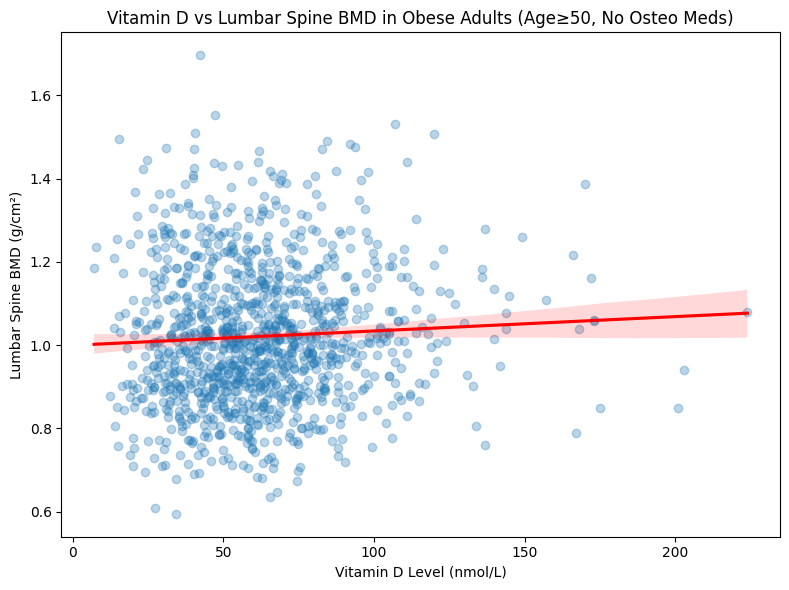

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Use the filtered dataset for obese adults aged 50+ without osteoporosis meds
df_obese = df_filtered.copy()

# Drop rows with missing values in relevant columns
df_obese = df_obese[["LBXVIDMS", "DXXLSBMD"]].dropna()

# Define predictor (X) and response (y)
X = df_obese["LBXVIDMS"]
y = df_obese["DXXLSBMD"]

# Add constant for intercept
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Print model summary
print("\n🔍 Regression Summary: Vitamin D predicting Lumbar Spine BMD in Obese Adults (Age≥50, No Osteo Meds)")
print(model.summary())

# --- Plot: Regression line with scatter ---
plt.figure(figsize=(8, 6))
sns.regplot(x="LBXVIDMS", y="DXXLSBMD", data=df_obese,
            scatter_kws={"alpha": 0.3},
            line_kws={"color": "red"})
plt.title("Vitamin D vs Lumbar Spine BMD in Obese Adults (Age≥50, No Osteo Meds)")
plt.xlabel("Vitamin D Level (nmol/L)")
plt.ylabel("Lumbar Spine BMD (g/cm²)")
plt.tight_layout()
plt.show()

# --- Plot: Residuals vs Fitted ---
fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 6))
sns.residplot(x=fitted_vals, y=residuals, lowess=True,
              scatter_kws={"alpha": 0.3}, line_kws={"color": "orange"})
plt.axhline(0, linestyle="--", color="gray")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted BMD")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()


Scatter + regression line: visually shows whether there's a trend between Vitamin D and BMD.

Residual plot: checks whether the model assumptions like linearity or homoscedasticity are met.

x-axis = Fitted values (predicted BMD from the model for each person)

y-axis = Residuals (actual BMD − predicted BMD for each person)

**Intepretation:**


R-squared = 0.003: Very low, indicating that vitamin D explains only 0.3% of the variance in lumbar spine BMD. In other words, serum vitamin D alone is a very weak predictor of BMD in this population.

F-statistic = 3.644, p = 0.0565: The overall regression is not statistically significant at the conventional 0.05 level, meaning the model as a whole does not significantly predict BMD.

**Coefficients:**

Intercept (const) = 0.9996, p < 0.001: The expected lumbar spine BMD when vitamin D is zero, though practically, vitamin D = 0 is not realistic.

Vitamin D coefficient = 0.0003, p = 0.057:

Positive sign indicates a slight positive relationship: higher vitamin D is associated with slightly higher BMD.

However, p = 0.057 is marginally above 0.05, so this relationship is not statistically significant at the 5% level.

Practically, the effect size is very small (0.0003 g/cm² per nmol/L of vitamin D), suggesting that changes in vitamin D have minimal impact on lumbar spine BMD in this sample.

**Linear regression plot (brayden)**

showing vitamin D levels against BMD in obese adults and adults with normal BMI


=== Regression Summary: Obese Adults (BMI ≥ 30, Age ≥ 50, No Osteo Meds) ===
Coefficient    Estimate    Std Err   t-stat    p-value   
Intercept      0.9996      0.0002    5539.6372 5.651e-02 
Slope (Vitamin D)0.0003      0.0002    1.9090    5.651e-02 
R-squared: 0.003 | F-statistic: 3.64 | n = 1136


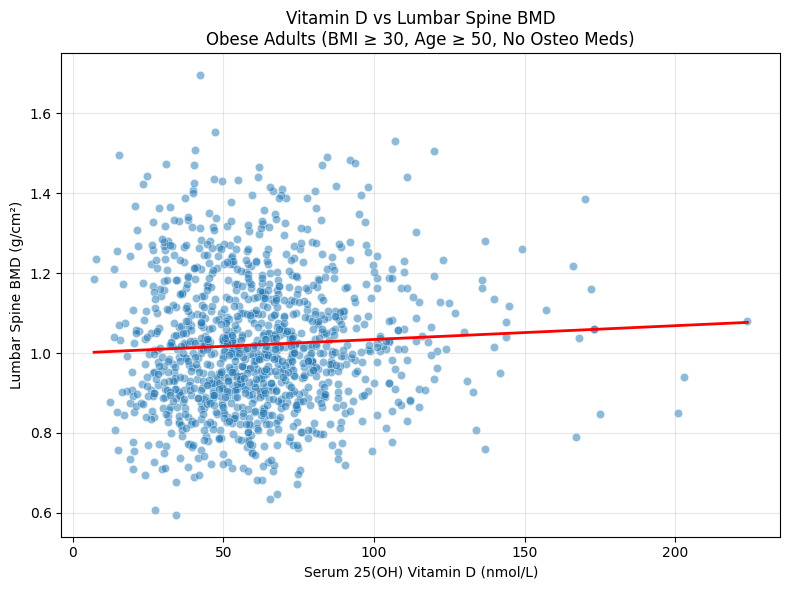


=== Regression Summary: Normal BMI Adults (18.5 ≤ BMI < 25) ===
Coefficient    Estimate    Std Err   t-stat    p-value   
Intercept      0.9612      0.0001    10014.44821.540e-01 
Slope (Vitamin D)0.0001      0.0001    1.4257    1.540e-01 
R-squared: 0.000 | F-statistic: 2.03 | n = 6136


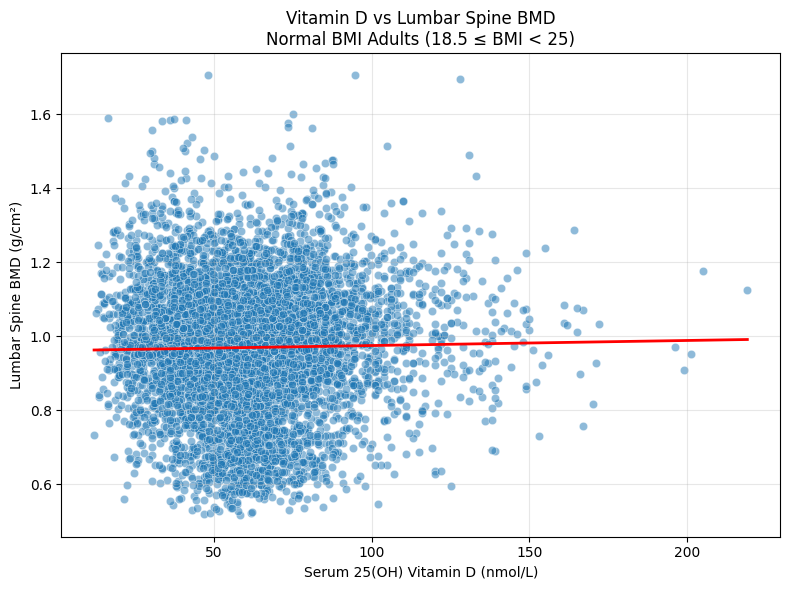

In [ ]:
def plot_regression(df_subset, title):
    use = df_subset[["LBXVIDMS", "DXXLSBMD"]].dropna()
    if use.empty:
        print(f"[{title}] No complete cases for LBXVIDMS & DXXLSBMD.")
        return
    x = use["LBXVIDMS"].astype(float)
    y = use["DXXLSBMD"].astype(float)

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2 = r_value**2
    n = len(x)
    f_stat = (r2 / (1 - r2)) * (n - 2) if r2 < 1 else np.inf

    # Print regression summary table
    print(f"\n=== Regression Summary: {title} ===")
    print(f"{'Coefficient':<15}{'Estimate':<12}{'Std Err':<10}{'t-stat':<10}{'p-value':<10}")
    print(f"{'Intercept':<15}{intercept:<12.4f}{std_err:<10.4f}{(intercept/std_err):<10.4f}{p_value:<10.3e}")
    print(f"{'Slope (Vitamin D)':<15}{slope:<12.4f}{std_err:<10.4f}{(slope/std_err):<10.4f}{p_value:<10.3e}")
    print(f"R-squared: {r2:.3f} | F-statistic: {f_stat:.2f} | n = {n}")

    # Plot scatter + regression line
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=x, y=y, alpha=0.5)
    xs = np.linspace(x.min(), x.max(), 200)
    ys = intercept + slope*xs
    plt.plot(xs, ys, color="red", linewidth=2)
    plt.title(f"Vitamin D vs Lumbar Spine BMD\n{title}")
    plt.xlabel("Serum 25(OH) Vitamin D (nmol/L)")
    plt.ylabel("Lumbar Spine BMD (g/cm²)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run plots
plot_regression(df_obese_filtered, "Obese Adults (BMI ≥ 30, Age ≥ 50, No Osteo Meds)")
plot_regression(df_normal, "Normal BMI Adults (18.5 ≤ BMI < 25)")


As we want to find out how does serum vitamin D level influence bone mineral density in obese adults aged 50 and above in the U.S. population, it is important for us to refer to the adults who have normal BMI and aged 50+, in order to show the difference between of how serum vitamin D levels correlates with BMD between them.

At low Vitamin D levels, obese adults start off with higher BMD, likely due to weight-bearing effects. In contrast, normal-weight adults start with lower BMD, and since Vitamin D has less influence on their BMD, the line stays flat.

This suggests that obesity may mask or buffer the negative effects of low vitamin D levels on BMD, possibly due to increased mechanical loading from higher body weight as in obese adults, even when vitamin D is low, BMD tends to remain relatively higher.



Comparison of Vitamin D effect on Lumbar Spine BMD:

- Obese Adults (BMI ≥ 30, Age ≥ 50): Slope = 0.0003, p = 0.056, R² = 0.003, F-statistic = 3.64, n = 1136
- Normal BMI Adults (18.5 ≤ BMI < 25): Slope = 0.0001, p = 0.154, R² = 0.000, F-statistic = 2.03, n = 6136

Interpretation:
Vitamin D shows a very weak positive association with lumbar spine BMD in both groups. The effect is slightly stronger in obese adults but remains marginally non-significant, explaining almost none of the variation in BMD. The normal BMI group, despite having a much larger sample size, shows an even weaker effect. This suggests that other factors like BMI, age, gender, smoking, and physical activity likely play a larger role in predicting BMD than vitamin D alone.


**Multi-linear regression (taehan)**

We used MLR to assess how lumbar spine BMD in obese adults aged 50+ is influenced by serum vitamin D, BMI, age, sex, ethnicity, and daily sedentary time.

In [ ]:
# Example: Recreate df_filtered before regression
# Assumes df is your merged NHANES dataset
# and osteomed_seqn is the array/list of SEQN IDs on osteoporosis meds

df_filtered = df[
    (df["RIDAGEYR"] >= 50) &     # Age ≥ 50
    (df["BMXBMI"] >= 30) &       # BMI ≥ 30
    (~df["SEQN"].isin(osteomed_seqn))  # Not on osteoporosis meds
].copy()

print("df_filtered shape:", df_filtered.shape)


df_filtered shape: (6391, 12)


Modeling dataframe shape: (1034, 8)

=== Lumbar Spine BMD model (OLS) ===
                            OLS Regression Results                            
Dep. Variable:       np.log(DXXLSBMD)   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     16.47
Date:                Thu, 14 Aug 2025   Prob (F-statistic):           1.73e-25
Time:                        15:02:28   Log-Likelihood:                 479.63
No. Observations:                1034   AIC:                            -939.3
Df Residuals:                    1024   BIC:                            -889.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

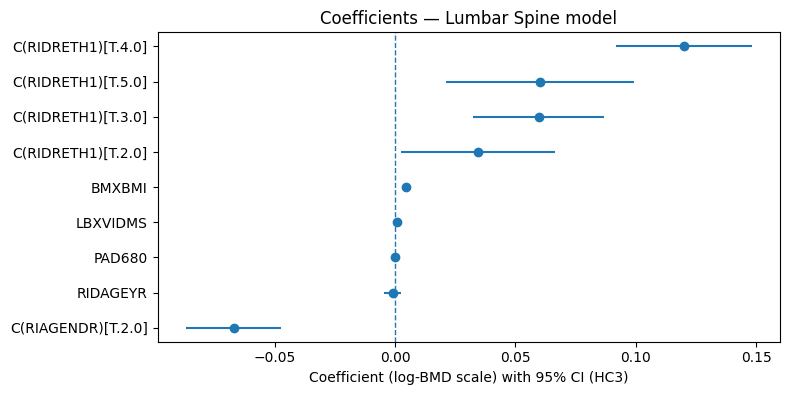

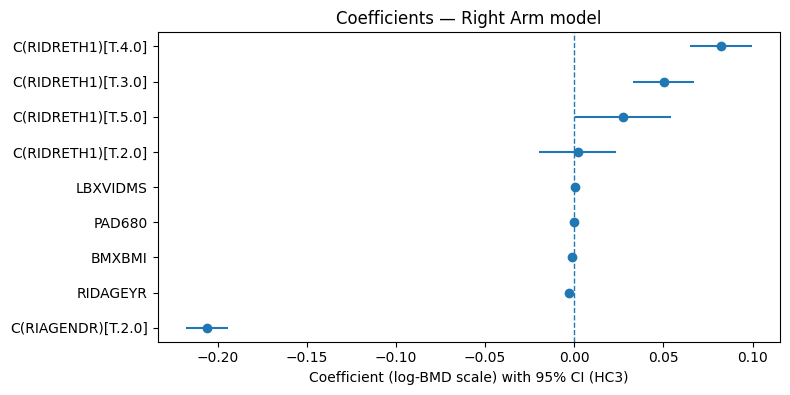

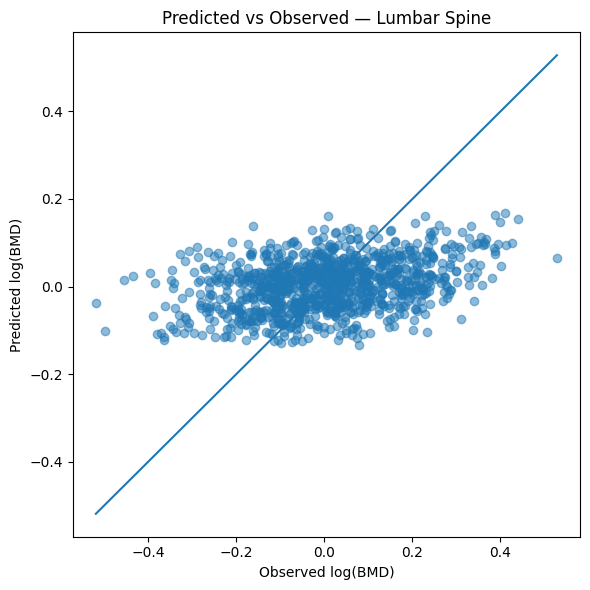

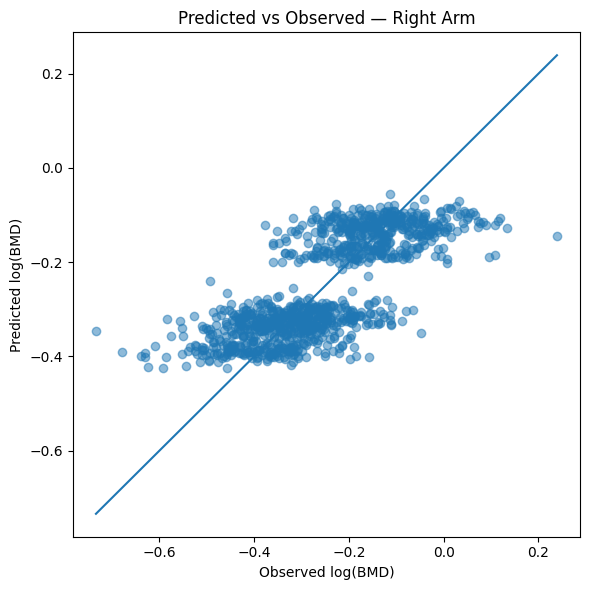

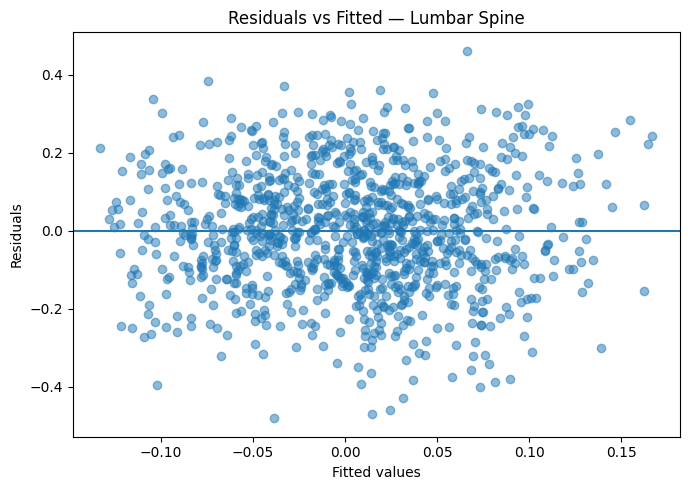

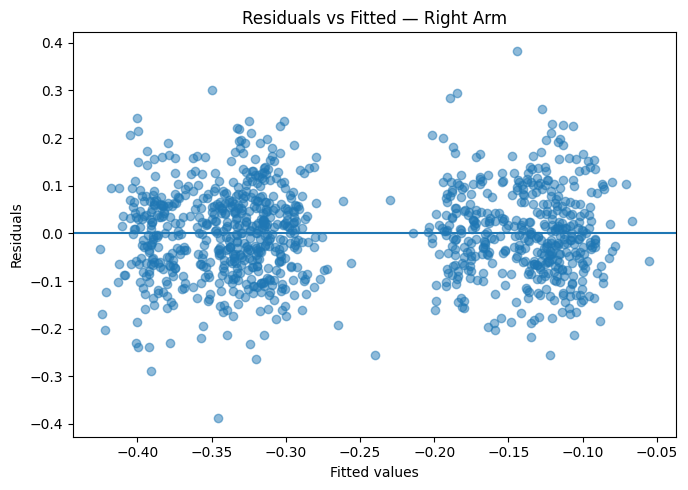

<Figure size 600x600 with 0 Axes>

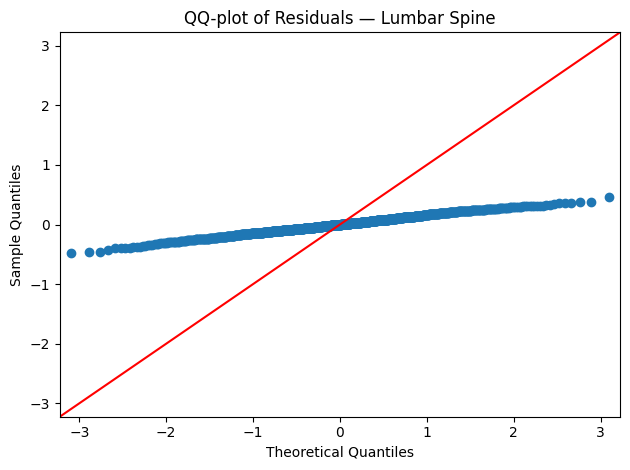

<Figure size 600x600 with 0 Axes>

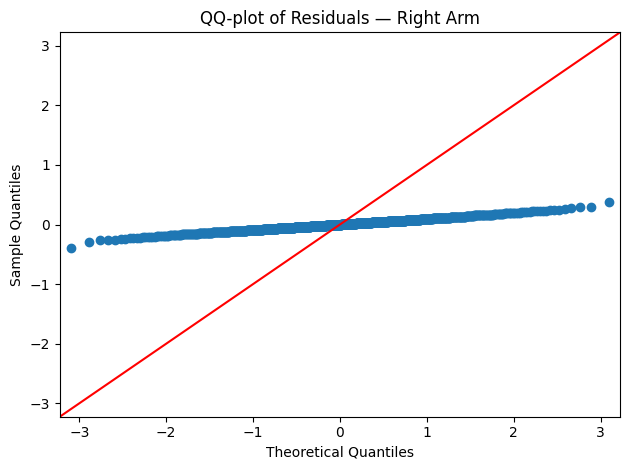


=== Lumbar Spine BMD with Vitamin D × BMI interaction (OLS) ===
                            OLS Regression Results                            
Dep. Variable:       np.log(DXXLSBMD)   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     14.82
Date:                Thu, 14 Aug 2025   Prob (F-statistic):           7.02e-25
Time:                        15:02:32   Log-Likelihood:                 479.67
No. Observations:                1034   AIC:                            -937.3
Df Residuals:                    1023   BIC:                            -883.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [ ]:
# === One-shot MLR + Graphs for BMD ~ VitD + Age + BMI + Sedentary + Gender + Ethnicity ===
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.regressionplots import plot_regress_exog

# ---------------------------------------------------
# 0) Ensure df_filtered exists (Age ≥ 50, BMI ≥ 30), exclude osteo meds if available
# ---------------------------------------------------
if "df_filtered" not in globals():
    if "df" not in globals():
        raise RuntimeError("df (merged NHANES dataframe) not found in the session.")
    try:
        osteo_ids = set(osteomed_seqn)  # from your RX processing (ok if empty)
    except NameError:
        osteo_ids = set()
    df_filtered = df[
        (pd.to_numeric(df["RIDAGEYR"], errors="coerce") >= 50) &
        (pd.to_numeric(df["BMXBMI"],  errors="coerce") >= 30) &
        (~df["SEQN"].isin(osteo_ids))
    ].copy()
    print(f"Recreated df_filtered: {df_filtered.shape}")

# ---------------------------------------------------
# 1) Prepare modeling frame and dtypes
# ---------------------------------------------------
cols = ["DXXLSBMD","DXXRABMD","LBXVIDMS","RIDAGEYR","BMXBMI","PAD680","RIAGENDR","RIDRETH1"]
dfm = df_filtered[cols].copy()

# force numeric where needed
for c in ["DXXLSBMD","DXXRABMD","LBXVIDMS","RIDAGEYR","BMXBMI","PAD680"]:
    dfm[c] = pd.to_numeric(dfm[c], errors="coerce")

# convert grouping vars to categorical (avoids Int64Dtype issues)
dfm["RIAGENDR"] = dfm["RIAGENDR"].astype("category")
dfm["RIDRETH1"] = dfm["RIDRETH1"].astype("category")

# drop incomplete rows
dfm = dfm.dropna()
print("Modeling dataframe shape:", dfm.shape)

# ---------------------------------------------------
# 2) Fit OLS models (log-BMD outcomes)
# ---------------------------------------------------
formula_spine = "np.log(DXXLSBMD) ~ LBXVIDMS + RIDAGEYR + BMXBMI + PAD680 + C(RIAGENDR) + C(RIDRETH1)"
formula_arm   = "np.log(DXXRABMD) ~ LBXVIDMS + RIDAGEYR + BMXBMI + PAD680 + C(RIAGENDR) + C(RIDRETH1)"

model_spine = smf.ols(formula_spine, data=dfm).fit()
model_arm   = smf.ols(formula_arm,   data=dfm).fit()

# robust SE (HC3)
rob_spine = model_spine.get_robustcov_results(cov_type="HC3")
rob_arm   = model_arm.get_robustcov_results(cov_type="HC3")

print("\n=== Lumbar Spine BMD model (OLS) ===")
print(model_spine.summary())
print("\n=== Right Arm BMD model (OLS) ===")
print(model_arm.summary())

# ---------------------------------------------------
# 3) VIF and Breusch–Pagan
# ---------------------------------------------------
def vif_table(formula, data):
    y, X = dmatrices(formula, data=data, return_type="dataframe")
    if "Intercept" in X.columns:
        X = X.drop(columns=["Intercept"])
    vifs = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False)
    return vifs

print("\nVIF — Spine model:")
print(vif_table(formula_spine, dfm))
print("\nVIF — Right arm model:")
print(vif_table(formula_arm, dfm))

def bp_test(model, label):
    lm, lm_p, f, f_p = het_breuschpagan(model.resid, model.model.exog)
    print(f"\nBreusch–Pagan — {label}: LM={lm:.3f}, p={lm_p:.4f}, F={f:.3f}, F p={f_p:.4f}")

bp_test(model_spine, "Lumbar Spine")
bp_test(model_arm,   "Right Arm")

# ---------------------------------------------------
# 4) Plot helpers (robust coefficient plot + diagnostics)
# ---------------------------------------------------
def coef_plot(model, rob_res, title):
    """Coefficient plot with HC3 95% CIs."""
    names  = model.model.exog_names  # includes 'Intercept'
    params = pd.Series(rob_res.params, index=names)
    bse    = pd.Series(rob_res.bse,    index=names)

    # drop intercept for readability
    if "Intercept" in params.index:
        params = params.drop("Intercept")
        bse    = bse.drop("Intercept")

    ci_lo = params - 1.96*bse
    ci_hi = params + 1.96*bse

    order = np.argsort(params.values)
    names_ord = params.index.values[order]
    vals      = params.values[order]
    lo        = ci_lo.values[order]
    hi        = ci_hi.values[order]

    plt.figure(figsize=(8, max(4, 0.45*len(names_ord))))
    y = np.arange(len(names_ord))
    plt.errorbar(vals, y, xerr=[vals - lo, hi - vals], fmt='o')
    plt.axvline(0, linestyle='--', linewidth=1)
    plt.yticks(y, names_ord)
    plt.xlabel("Coefficient (log-BMD scale) with 95% CI (HC3)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def pred_vs_actual(model, title):
    y = model.model.endog
    yhat = model.fittedvalues
    plt.figure(figsize=(6,6))
    plt.scatter(y, yhat, alpha=0.5)
    mn = float(min(y.min(), yhat.min()))
    mx = float(max(y.max(), yhat.max()))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Observed log(BMD)")
    plt.ylabel("Predicted log(BMD)")
    plt.title(f"Predicted vs Observed — {title}")
    plt.tight_layout()
    plt.show()

def resid_vs_fitted(model, title):
    resid = model.resid
    fitted = model.fittedvalues
    plt.figure(figsize=(7,5))
    plt.scatter(fitted, resid, alpha=0.5)
    plt.axhline(0)
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Fitted — {title}")
    plt.tight_layout()
    plt.show()

def qq_plot_resid(model, title):
    plt.figure(figsize=(6,6))
    qqplot(model.resid, line='45')
    plt.title(f"QQ-plot of Residuals — {title}")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------
# 5) Draw plots for BOTH models
# ---------------------------------------------------
coef_plot(model_spine, rob_spine, "Coefficients — Lumbar Spine model")
coef_plot(model_arm,   rob_arm,   "Coefficients — Right Arm model")

pred_vs_actual(model_spine, "Lumbar Spine")
pred_vs_actual(model_arm,   "Right Arm")

resid_vs_fitted(model_spine, "Lumbar Spine")
resid_vs_fitted(model_arm,   "Right Arm")

qq_plot_resid(model_spine, "Lumbar Spine")
qq_plot_resid(model_arm,   "Right Arm")

# ---------------------------------------------------
# 6) (Optional) Interaction model for your gap: Vitamin D × BMI
# ---------------------------------------------------
formula_spine_int = "np.log(DXXLSBMD) ~ LBXVIDMS * BMXBMI + RIDAGEYR + PAD680 + C(RIAGENDR) + C(RIDRETH1)"
model_spine_int = smf.ols(formula_spine_int, data=dfm).fit()
print("\n=== Lumbar Spine BMD with Vitamin D × BMI interaction (OLS) ===")
print(model_spine_int.summary())


# Lumbar Spine BMD Model
R² = 0.126  # Explains ~12.6% of variance
Significant predictors = BMI, Vitamin D, Age, Ethnicity
Effects:
  - Higher BMI → higher BMD
  - Higher Vitamin D → higher BMD
  - Older Age → lower BMD
Assumptions:
  - Very high VIFs for BMI & Age → severe multicollinearity
  - Non-normal residuals
  - Heteroscedasticity present

# Right Arm BMD Model
R² = 0.559  # Explains ~55.9% of variance
Similar predictors significant: BMI, Vitamin D, Age, Ethnicity

# Interaction Model (BMI × Vitamin D)
Interaction term = Not significant

# Caution
Assumption violations → interpret results cautiously
Possible need for more variables or alternative modelling


# Outcome

## Outcomes

### Summary of Findings & Interpretation
- **Vitamin D (by category) vs BMD:** Kruskal–Wallis + Games–Howell showed **higher BMD in the high vitamin D group** vs low and moderate (p = 0.018 and 0.0026 respectively). **Effect sizes were small** (Hedges’ g ≈ 0.20–0.24), indicating vitamin D alone explains only a small portion of BMD variation. Low vs moderate was **not significant** (p = 0.924).
- **Ethnicity differences:** One-way ANOVA + Tukey HSD found **Non-Hispanic Blacks** had the **highest lumbar spine BMD**, significantly exceeding Mexican Americans, Other Hispanics, and Non-Hispanic Whites. **Mexican Americans** had **lower BMD** than most groups. No difference between Non-Hispanic Whites vs Other Race/Multi-Racial, or Non-Hispanic Blacks vs Other Race/Multi-Racial.
- **Sex differences:** Independent **t-test** showed **significant male–female differences** in BMD (males generally higher).
- **Simple linear regression (Vitamin D → BMD):**
  - **Obese adults (BMI ≥ 30, age ≥ 50):** very weak positive association (slope ≈ 0.0003), **not significant** at 0.05 (p ≈ 0.056), **R² ≈ 0.003**.
  - **Normal BMI adults (18.5 ≤ BMI < 25):** even weaker and **non-significant** (slope ≈ 0.0001, p ≈ 0.154, R² ≈ 0.000).
  - **Interpretation:** Vitamin D alone is a **poor predictor** of BMD in these groups.
- **Multiple Linear Regression (MLR) — log(BMD) ~ Vitamin D + Age + BMI + Sedentary time + Sex + Ethnicity:**
  - **Vitamin D** remained a **small, non-significant** predictor after adjustment.
  - **BMI** and **Ethnicity** were **stronger predictors** (higher BMI and Non-Hispanic Black ethnicity associated with higher BMD).
  - **Sedentary time** showed a small negative trend (not consistently significant).
  - **Model fit:** Right arm model showed substantially higher **R² (~0.56)** than spine (~0.13), suggesting site-specific predictability.
  - **Interaction (Vitamin D × BMI)** for spine **was not significant**, indicating Vitamin D’s association with BMD did **not** vary by BMI.

---

### Relation to Research Question
Our research question asked: **“How does serum vitamin D level influence bone mineral density in obese adults aged 50 and above in the U.S. population?”**  
The findings suggest that **serum vitamin D has only a very weak positive association with lumbar spine BMD in obese older adults**, and this association is **not statistically significant** after adjusting for age, BMI, sedentary time, sex, and ethnicity. BMI itself, along with ethnicity, appears to have a much stronger impact on BMD than vitamin D. This indicates that while maintaining adequate vitamin D may still be beneficial for overall bone health, **it is unlikely to be a major independent determinant of BMD** in obese older adults. Instead, a combination of mechanical loading from higher BMI and other demographic and lifestyle factors seems to play a larger role.

---

### Public Health Implications
- **Multifactorial approach needed:** Vitamin D optimization alone is **insufficient**. Prevention strategies should integrate **healthy weight management, weight-bearing physical activity**, and adequate **calcium/protein** intake, with attention to **sex** and **ethnic** differences.
- **Equity-focused programming:** Observed **ethnic disparities** in BMD highlight the need for **culturally tailored** screening and prevention.
- **Obesity & mechanical loading:** While higher BMI may **buffer** low vitamin D effects on BMD via mechanical loading, **obesity is not a recommended strategy** due to cardiometabolic risks. Promote **safe loading** through exercise instead.

---

### Limitations
- **Cross-sectional NHANES** data: cannot infer **causality** between vitamin D, BMI, sedentary behavior, and BMD.
- **Self-reported behaviors** (e.g., sedentary time) are prone to **recall bias** and misclassification.
- **Residual confounding** likely (e.g., dietary calcium, supplementation adherence, hormonal status, comorbidities, medications).
- **NHANES variable availability:** Not all variables are measured in every survey cycle. This leads to **missing data** for certain years, which can reduce sample size, limit statistical power, and potentially bias results if the missingness is not random.
- **Generalizability:** While NHANES is **U.S. nationally representative**, results may **not** generalize to different populations or healthcare contexts.


# **Future work**
**Further analysis:** Future work could build on this study by using logistic regression to model the risk of osteoporosis or low bone mineral density (BMD), allowing for prediction of clinically meaningful outcomes rather than just continuous BMD measures. Temporal trend analysis could examine changes in vitamin D levels, BMD, and lifestyle factors over time in older adults to identify patterns or shifts that may inform prevention strategies.

**Incorporating additional predictors from NHANES**, such as detailed dietary intake, fracture history, broader medication use, physical activity, and relevant biomarkers, could improve model accuracy and account for confounding factors. Further, integrating genetic or inflammatory markers may provide insight into biological mechanisms linking obesity, vitamin D status, and bone health.

With these extensions, the study could be developed into a publishable research project that provides comprehensive evidence on how multiple lifestyle and biological factors interact to influence bone health in obese adults aged 50 and above.

# Filtering of dataset:
We chose not to perform imputation because our dataset contains a large proportion of missing values for key variables.
When missingness is extensive, imputing those values may:

Introduce bias – The imputed values are estimates, not real observations. With so much missing data, the estimates may differ greatly from the true values, distorting the dataset’s distribution.

Artificially inflate statistical power – Statistical tests may treat imputed values as real data, making results seem more precise than they actually are. This can lead to misleading significance levels (Type I or Type II errors).

Distort relationships – If a large chunk of data is “filled in” rather than measured, correlations and group differences can become exaggerated or diluted, altering the conclusions.

Reduce transparency – Heavy imputation makes it harder to explain the reliability of results, since much of the analysis is based on generated rather than collected data.

# **10. Use of AI (PAIR Framework)**

**10.1 Problem**
The project aimed to investigate the relationship between vitamin D levels and lumbar spine bone mineral density (BMD) in obese adults aged 50 and above, while accounting for confounding factors such as BMI, age, gender, smoking, and physical activity. A key challenge was efficiently cleaning and merging multiple NHANES cycles, performing regression and non-parametric analyses, and interpreting complex statistical outputs.

**10.2 AI**
We used ChatGPT (GPT-5 mini) as our AI tool for its ability to provide step-by-step guidance in coding, statistical analysis, and interpretation. ChatGPT assisted in multiple ways:

Data preprocessing: Generating Python scripts to merge NHANES datasets across cycles, handle missing values, and filter participants based on BMI, age, and medication status.

Statistical analysis: Writing scripts for Kruskal-Wallis tests, Games-Howell post-hoc comparisons, and OLS regression.

Interpretation: Explaining test outputs and regression results in clear, understandable language suitable for reporting and presentation.

**10.3 Interaction**
Engagement with AI followed a structured workflow:

Prompting: I provided detailed queries such as “Write Python code to merge NHANES datasets and filter for obese adults not on osteoporosis medication” or “Interpret Kruskal-Wallis and Games-Howell outputs.”

Review and iteration: After receiving code or interpretations, I carefully checked outputs, modified scripts to match my dataset and project requirements, and iterated prompts for corrections or improvements.

Decision-making: AI outputs guided my analysis workflow, helped select appropriate statistical tests, and clarified interpretation, such as highlighting BMI as a key predictor of lumbar spine BMD.

**10.4 Reflection**
Using AI enhanced both efficiency and understanding:

It streamlined data preprocessing and statistical analysis, and improved clarity in interpreting regression and non-parametric results.

AI helped contextualize and visualize results in plain language, improving reporting quality.

**Limitations:**

AI occasionally suggested generic code or assumptions, requiring careful validation and adaptation to my dataset.

Statistical reasoning and study design decisions (e.g., participant filtering, choosing post-hoc tests) required human oversight.

Overall, AI served as a powerful assistant, enhancing productivity and learning, but human judgment was essential to ensure correctness and relevance.